# Neural Enhancement of WEB-Spline Collocation Solutions

## Summary of Results

This notebook summarizes the investigation of **neural network-based enhancement** of WEB-spline collocation solutions for the Poisson equation $-\Delta u = f$ on complex 2D domains.

### Domains Studied
1. **Triangle** — convex polygon with signed halfplane distances combined via R-function
2. **Elliptic Pentagon** — five-sided domain from ellipse arc intersections with algebraic distances

### Methodology

**WEB-Spline Collocation:** The baseline solver uses WEB-spline (Weighted Extended B-spline) collocation on a uniform grid. The domain $\Omega = \{(x,y) : w(x,y) > 0\}$ is implicitly defined by a smooth weight function $w$. B-splines are multiplied by $\max(w, 0)$ to enforce homogeneous Dirichlet boundary conditions.

**Manufactured Solution:** We use $u_{\text{exact}} = e^w - 1$ (denoted `expw`), which is zero on $\partial\Omega$ and non-polynomial, providing a challenging test case. The RHS $f = -\Delta u_{\text{exact}}$ is computed analytically.

**Neural Enhancement Ansatz:**
$$u_{\text{corrected}} = u_{\text{colloc}} + \psi \cdot u_{\text{nn}}$$

where $\psi(x,y) = w(x,y) \cdot \varphi\!\left(\frac{\text{SDF}(x,y)}{\epsilon}\right)$ with a polynomial compact-support cutoff $\varphi(s) = \max(0, 1-s^2)^3$.

- $\psi$ vanishes **both** at the boundary ($w=0$) and in the interior ($\text{SDF} > \epsilon$), so the correction only acts in a narrow near-boundary band.
- The neural network $u_{\text{nn}}$ takes as input the **signed distances** from each boundary edge/ellipse.
- Training minimizes $\mathcal{L} = \| \Delta(\psi \cdot u_{\text{nn}}) + r_{\text{colloc}} \|^2$ where $r_{\text{colloc}} = \Delta u_{\text{colloc}} + f$ is the PDE residual.

**Network Architectures Compared:**
- **SIREN** (Sinusoidal Representation Networks): $\sin(\omega \cdot Wx + b)$ activations
- **KAN** (Kolmogorov-Arnold Networks): learnable spline-based activations

### Key Questions
1. Does neural enhancement reduce solution and derivative errors?
2. How does the benefit depend on collocation resolution (low vs high H)?
3. What are the pros and cons of SIREN vs KAN?
4. Where (spatially) does the enhancement help most?

In [1]:
import os, sys, time, importlib
from dataclasses import dataclass
from typing import Callable, Dict, Optional, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from scipy.interpolate import RectBivariateSpline

NA_DIR = os.path.join(os.getcwd(), "Neural Analysis")
if NA_DIR not in sys.path:
    sys.path.insert(0, NA_DIR)

import collocation_WEB as colloc
import Geomertry as geom
import network_defs

importlib.reload(geom)
importlib.reload(colloc)
importlib.reload(network_defs)

plt.rcParams.update({"figure.dpi": 150, "font.size": 10})

np.random.seed(0)
torch.manual_seed(0)
torch.set_default_dtype(torch.float64)

# === Configuration ===
U_EXACT_TYPE = "expw"
PLOT_UPSAMPLE = 6  # Increased from 4 for smoother visualization
CONTOUR_LEVELS = 100
DOMAIN_M11 = {"x1": -1.0, "x2": 1.0, "y1": -1.0, "y2": 1.0}

# Collocation resolutions to compare
DEGREES = [2, 4]
HS_LOW = [32]       # lower resolution
HS_HIGH = [128]     # higher resolution
HS_ALL = [32, 128]

# Neural correction parameters
EPS_BAND = 0.04
NUM_EPOCHS = 1000
BATCH_SIZE = 2000
POOL_SIZE = 500000

print("Setup complete.")


Setup complete.


In [2]:
# ==========================================================================
# Shared Helper Functions
# ==========================================================================

def zero_fn(x, y):
    return np.zeros_like(np.asarray(x, dtype=np.float64))


@dataclass(frozen=True)
class GeometryVariant:
    name: str
    model: torch.nn.Module
    domain: Optional[Dict[str, float]]
    geom_type: str  # 'polygon' or 'ellipse'


def make_manufactured_problem(model, u_type="expw"):
    wfct_phys = colloc.NeuralWeightFunction(model, domain=None, transform=None)
    if u_type == "expw":
        def u_exact_phys(xp, yp):
            w, *_ = wfct_phys(xp, yp)
            return np.exp(w) - 1.0
        def f_phys(xp, yp):
            w, wx, wy, wxx, wyy = wfct_phys(xp, yp)
            return -(np.exp(w) * (wx**2 + wy**2 + wxx + wyy))
    elif u_type == "w2":
        def u_exact_phys(xp, yp):
            w, *_ = wfct_phys(xp, yp)
            return w**2
        def f_phys(xp, yp):
            w, wx, wy, wxx, wyy = wfct_phys(xp, yp)
            return -(2.0 * (wx**2 + wy**2) + 2.0 * w * (wxx + wyy))
    else:
        raise ValueError(f"Unknown u_type={u_type}")
    return f_phys, u_exact_phys, wfct_phys


def transform_grid_to_physical(xg, yg, domain):
    if domain is None:
        return np.asarray(xg, dtype=np.float64), np.asarray(yg, dtype=np.float64)
    sx = domain["x2"] - domain["x1"]
    sy = domain["y2"] - domain["y1"]
    return domain["x1"] + np.asarray(xg, dtype=np.float64) * sx, \
           domain["y1"] + np.asarray(yg, dtype=np.float64) * sy


def compute_near_boundary_binning(w_inside, err_inside, n_bins=30, w_max=None):
    w_inside = np.asarray(w_inside, dtype=np.float64).ravel()
    err_inside = np.asarray(err_inside, dtype=np.float64).ravel()
    mask = np.isfinite(w_inside) & np.isfinite(err_inside)
    w_inside, err_inside = w_inside[mask], err_inside[mask]
    if w_inside.size == 0:
        return pd.DataFrame({"w_mid": [], "err_mean": [], "count": []})
    if w_max is None:
        w_max = float(np.quantile(w_inside, 0.995))
    w_max = max(w_max, 1e-12)
    edges = np.linspace(0.0, w_max, n_bins + 1)
    rows = []
    for i in range(n_bins):
        sel = (w_inside >= edges[i]) & (w_inside < edges[i + 1])
        if np.any(sel):
            rows.append({"w_mid": 0.5*(edges[i]+edges[i+1]),
                         "err_mean": float(np.mean(err_inside[sel])),
                         "count": int(np.sum(sel))})
    return pd.DataFrame(rows)


def compute_exact_derivatives(wfct_phys, pts_x, pts_y, u_type="expw"):
    w, wx, wy, wxx, wyy = wfct_phys(pts_x, pts_y)
    w, wx, wy, wxx, wyy = [np.asarray(a).ravel() for a in (w, wx, wy, wxx, wyy)]
    if u_type == "expw":
        ew = np.exp(w)
        return ew * wx, ew * wy, ew * (wx**2 + wxx), ew * (wy**2 + wyy)
    elif u_type == "w2":
        return (2*w*wx, 2*w*wy, 2*(wx**2 + w*wxx), 2*(wy**2 + w*wyy))
    raise ValueError(f"Unknown u_type={u_type}")


def _clip_contourf_to_boundary(cf, ax, boundary_pts):
    """Clip contourf to polygon boundary. Works with all matplotlib versions."""
    from matplotlib.patches import Polygon as MplPolygon
    import matplotlib.collections as mcoll
    clip_patch = MplPolygon(boundary_pts, closed=True, transform=ax.transData,
                            facecolor="none", edgecolor="none")
    ax.add_patch(clip_patch)
    # matplotlib < 3.8: collections is a list of PolyCollection
    # matplotlib >= 3.8: collections is deprecated; use axes children
    collections = getattr(cf, 'collections', None)
    if collections:
        for coll in collections:
            try:
                coll.set_clip_path(clip_patch)
            except Exception:
                pass
    else:
        for child in ax.get_children():
            if isinstance(child, (mcoll.PolyCollection, mcoll.PathCollection)):
                child.set_clip_path(clip_patch)


def get_boundary_pts(gv):
    """Get boundary points for clipping, depending on geometry type."""
    if gv.geom_type == 'ellipse':
        return gv.model._boundary_pts
    else:
        return gv.model._vertices_np


def compute_sdf(pts_x, pts_y, gv):
    """Compute SDF (positive inside) for either geometry type.
    Output shape matches input shape (preserves 1D or 2D input).
    """
    if gv.geom_type == 'ellipse':
        return gv.model.min_algebraic_distance_numpy(pts_x, pts_y)
    else:
        orig_shape = np.asarray(pts_x).shape
        # Always flatten to (N, 2) for convex_polygon_sdf, then reshape back
        px = np.asarray(pts_x, dtype=np.float64).ravel()
        py = np.asarray(pts_y, dtype=np.float64).ravel()
        crd = torch.tensor(np.stack([px, py], axis=-1), dtype=torch.float64)
        verts_t = crd.new_tensor(gv.model._vertices_np)
        with torch.no_grad():
            result = geom.convex_polygon_sdf(crd, verts_t).numpy()
        return result.reshape(orig_shape) if orig_shape else result.ravel()


def point_inside(pts_x, pts_y, gv):
    """Check if points are inside the domain.
    Output shape matches input shape (preserves 1D or 2D input).
    """
    if gv.geom_type == 'ellipse':
        dists = gv.model.algebraic_distances_numpy(pts_x, pts_y)
        return np.all(np.stack(dists, axis=-1) > 0, axis=-1)
    else:
        orig_shape = np.asarray(pts_x).shape
        px = np.asarray(pts_x, dtype=np.float64).ravel()
        py = np.asarray(pts_y, dtype=np.float64).ravel()
        crd = torch.tensor(np.stack([px, py], axis=-1), dtype=torch.float64)
        verts_t = crd.new_tensor(gv.model._vertices_np)
        result = geom._point_in_convex_polygon_ccw(crd, verts_t).numpy()
        return result.reshape(orig_shape) if orig_shape else result.ravel()


print("Helper functions defined.")

Helper functions defined.


## 1. Domain Geometries

We study two representative geometries:
- **Triangle** (polygon, R-function weight): halfplane distances from 3 edges combined via the R0 R-function
- **Elliptic Pentagon** (curved boundary): algebraic distances from 5 ellipses, also combined via R0

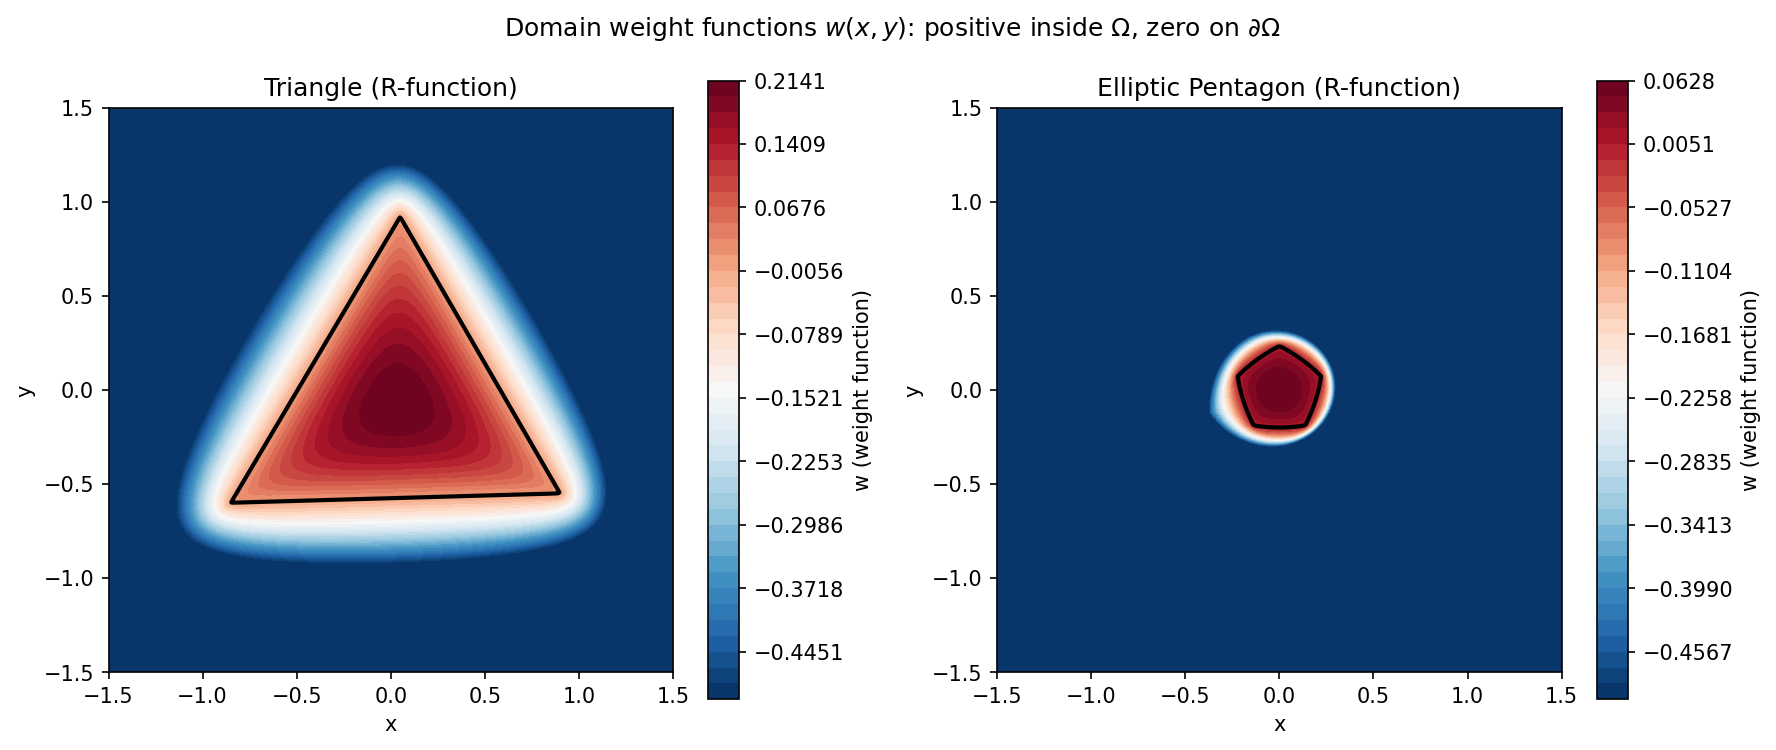

In [3]:
# ==========================================================================
# Define Geometries
# ==========================================================================

TRI_VERTS = np.array([[-0.85, -0.60], [0.90, -0.55], [0.05, 0.92]], dtype=np.float64)

triangle_model = geom.AnaliticalDistanceTriangle_RFunction(
    preserve_zero_line=True, vertices=TRI_VERTS)

ellipse_model = geom.AnaliticalDistanceEllipsePentagon_RFunction(
    n_sides=5, center_distance=1.5,
    semi_axis_tangential=1.2, semi_axis_radial=1.7,
    rotation_offset=np.pi / 2,
    preserve_zero_line=True, eps=1e-6)

GEOMS = [
    GeometryVariant(name="Triangle (R-function)",
                    model=triangle_model, domain=DOMAIN_M11, geom_type='polygon'),
    GeometryVariant(name="Elliptic Pentagon (R-function)",
                    model=ellipse_model, domain=DOMAIN_M11, geom_type='ellipse'),
]

# --- Visualize ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for idx, gv in enumerate(GEOMS):
    ax = axes[idx]
    # Expanded grid range for better domain coverage
    x = np.linspace(-1.5, 1.5, 400)
    y = np.linspace(-1.5, 1.5, 400)
    xg, yg = np.meshgrid(x, y)
    coords = torch.tensor(np.stack([xg, yg], axis=-1), dtype=torch.float64)
    with torch.no_grad():
        w_vis = gv.model(coords).numpy()
    w_vis_clipped = np.clip(w_vis, -0.5, 0.5)
    vmin, vmax = float(np.nanmin(w_vis_clipped)), float(np.nanmax(w_vis_clipped))
    if np.isclose(vmin, vmax):
        vmin -= 1e-6; vmax += 1e-6
    levels = np.linspace(vmin, vmax, 40)
    cf = ax.contourf(xg, yg, w_vis_clipped, levels=levels, cmap="RdBu_r")
    ax.contour(xg, yg, w_vis, levels=[0.0], colors="k", linewidths=2.0)
    fig.colorbar(cf, ax=ax, label="w (weight function)")
    ax.set_aspect("equal")
    ax.set_title(gv.name)
    ax.set_xlabel("x"); ax.set_ylabel("y")

fig.suptitle("Domain weight functions $w(x,y)$: positive inside $\\Omega$, zero on $\\partial\\Omega$",
             fontsize=12)
fig.tight_layout()
plt.show()


## 2. Collocation Solver: Baseline Errors

We run the WEB-spline collocation solver at two resolutions:
- **Low resolution**: $H = 32$ (fewer B-spline functions)
- **High resolution**: $H = 128$ (more B-spline functions)

For both, we examine $u$, $\nabla u$, and $\nabla^2 u$ errors.

In [4]:
# ==========================================================================
# Run collocation solver for all (geometry, degree, H) combinations
# ==========================================================================

def run_one(gv, n, H, CD_cache, verbose=False):
    """Run collocation solver and return result dict."""
    f_phys, u_exact_phys, wfct_phys = make_manufactured_problem(gv.model, u_type=U_EXACT_TYPE)
    wfct_grid = colloc.NeuralWeightFunction(gv.model, domain=gv.domain, transform=None)
    if n not in CD_cache:
        CD_cache[n] = colloc.compute_collocation_data(n, J_MAX=16)

    out = colloc.collocation_2d(
        n=n, H=H, wfct=wfct_grid, f=f_phys, CD=CD_cache[n],
        verbose=verbose, domain=gv.domain,
        solve_method="auto", dense_threshold=2000,
        g=zero_fn, gx=zero_fn, gy=zero_fn, gxx=zero_fn, gyy=zero_fn,
        return_coefficients=True)

    if not (isinstance(out, tuple) and len(out) == 7):
        raise ValueError(f"collocation_2d returned unexpected format")

    Uxy, xB, yB, con, dim_sys, rtimes, recon_info = out
    if Uxy is None:
        raise RuntimeError(f"Collocation failed for n={n}, H={H}")

    xP, yP = transform_grid_to_physical(xB, yB, gv.domain)
    wP, *_ = wfct_phys(xP, yP)
    uex = u_exact_phys(xP, yP)
    sdf_P = compute_sdf(xP, yP, gv)
    err = np.abs(Uxy - uex)
    inside = wP > 0
    err_inside = err[inside]
    sdf_inside = sdf_P[inside]

    summary = {
        "geom": gv.name, "n": int(n), "H": int(H), "dim_sys": int(dim_sys),
        "err_mean": float(np.mean(err_inside)) if err_inside.size else np.nan,
        "err_max": float(np.max(err_inside)) if err_inside.size else np.nan,
        "inside_count": int(err_inside.size),
    }
    bins = compute_near_boundary_binning(sdf_inside, err_inside, n_bins=30)

    return {
        "summary": summary, "Uxy": Uxy, "xP": xP, "yP": yP,
        "wP": wP, "err": err, "inside": inside, "bins": bins,
        "u_exact_phys": u_exact_phys, "wfct_phys": wfct_phys,
        "recon_info": recon_info, "model": gv.model, "gv": gv,
    }


# --- Run sweep ---
CD_cache = {}
all_summaries = []
all_results = {}

for gv in GEOMS:
    for n in DEGREES:
        for H in HS_ALL:
            key = (gv.name, n, H)
            print(f"Running: {gv.name} | n={n} | H={H} ... ", end="")
            try:
                res = run_one(gv, n=n, H=H, CD_cache=CD_cache)
                all_results[key] = res
                all_summaries.append(res["summary"])
                print(f"done. max_err={res['summary']['err_max']:.2e}")
            except Exception as e:
                print(f"FAILED: {e}")

summary_df = pd.DataFrame(all_summaries)
summary_df = summary_df.sort_values(["geom", "n", "H"]).reset_index(drop=True)
display(summary_df)

Running: Triangle (R-function) | n=2 | H=32 ... done. max_err=6.38e-04
Running: Triangle (R-function) | n=2 | H=128 ... done. max_err=8.15e-06
Running: Triangle (R-function) | n=4 | H=32 ... done. max_err=8.11e-03
Running: Triangle (R-function) | n=4 | H=128 ... done. max_err=1.63e-05
Running: Elliptic Pentagon (R-function) | n=2 | H=32 ... done. max_err=7.81e-05
Running: Elliptic Pentagon (R-function) | n=2 | H=128 ... done. max_err=5.74e-06
Running: Elliptic Pentagon (R-function) | n=4 | H=32 ... Error: Grid width 1/H too large - no fully inner element arrays
FAILED: Collocation failed for n=4, H=32
Running: Elliptic Pentagon (R-function) | n=4 | H=128 ... done. max_err=2.79e-06


,geom,n,H,dim_sys,err_mean,err_max,inside_count
0,Elliptic Pentagon (R-function),2,32,32,3.719727e-05,0.000078,32
1,Elliptic Pentagon (R-function),2,128,574,3.460218e-06,0.000006,574
2,Elliptic Pentagon (R-function),4,128,574,2.501698e-07,0.000003,574
3,Triangle (R-function),2,32,333,1.556538e-05,0.000638,333
4,Triangle (R-function),2,128,5353,4.106997e-07,0.000008,5353
5,Triangle (R-function),4,32,333,1.146217e-04,0.008110,333
6,Triangle (R-function),4,128,5353,1.117995e-07,0.000016,5353


### 2.1 Solution Error Heatmaps

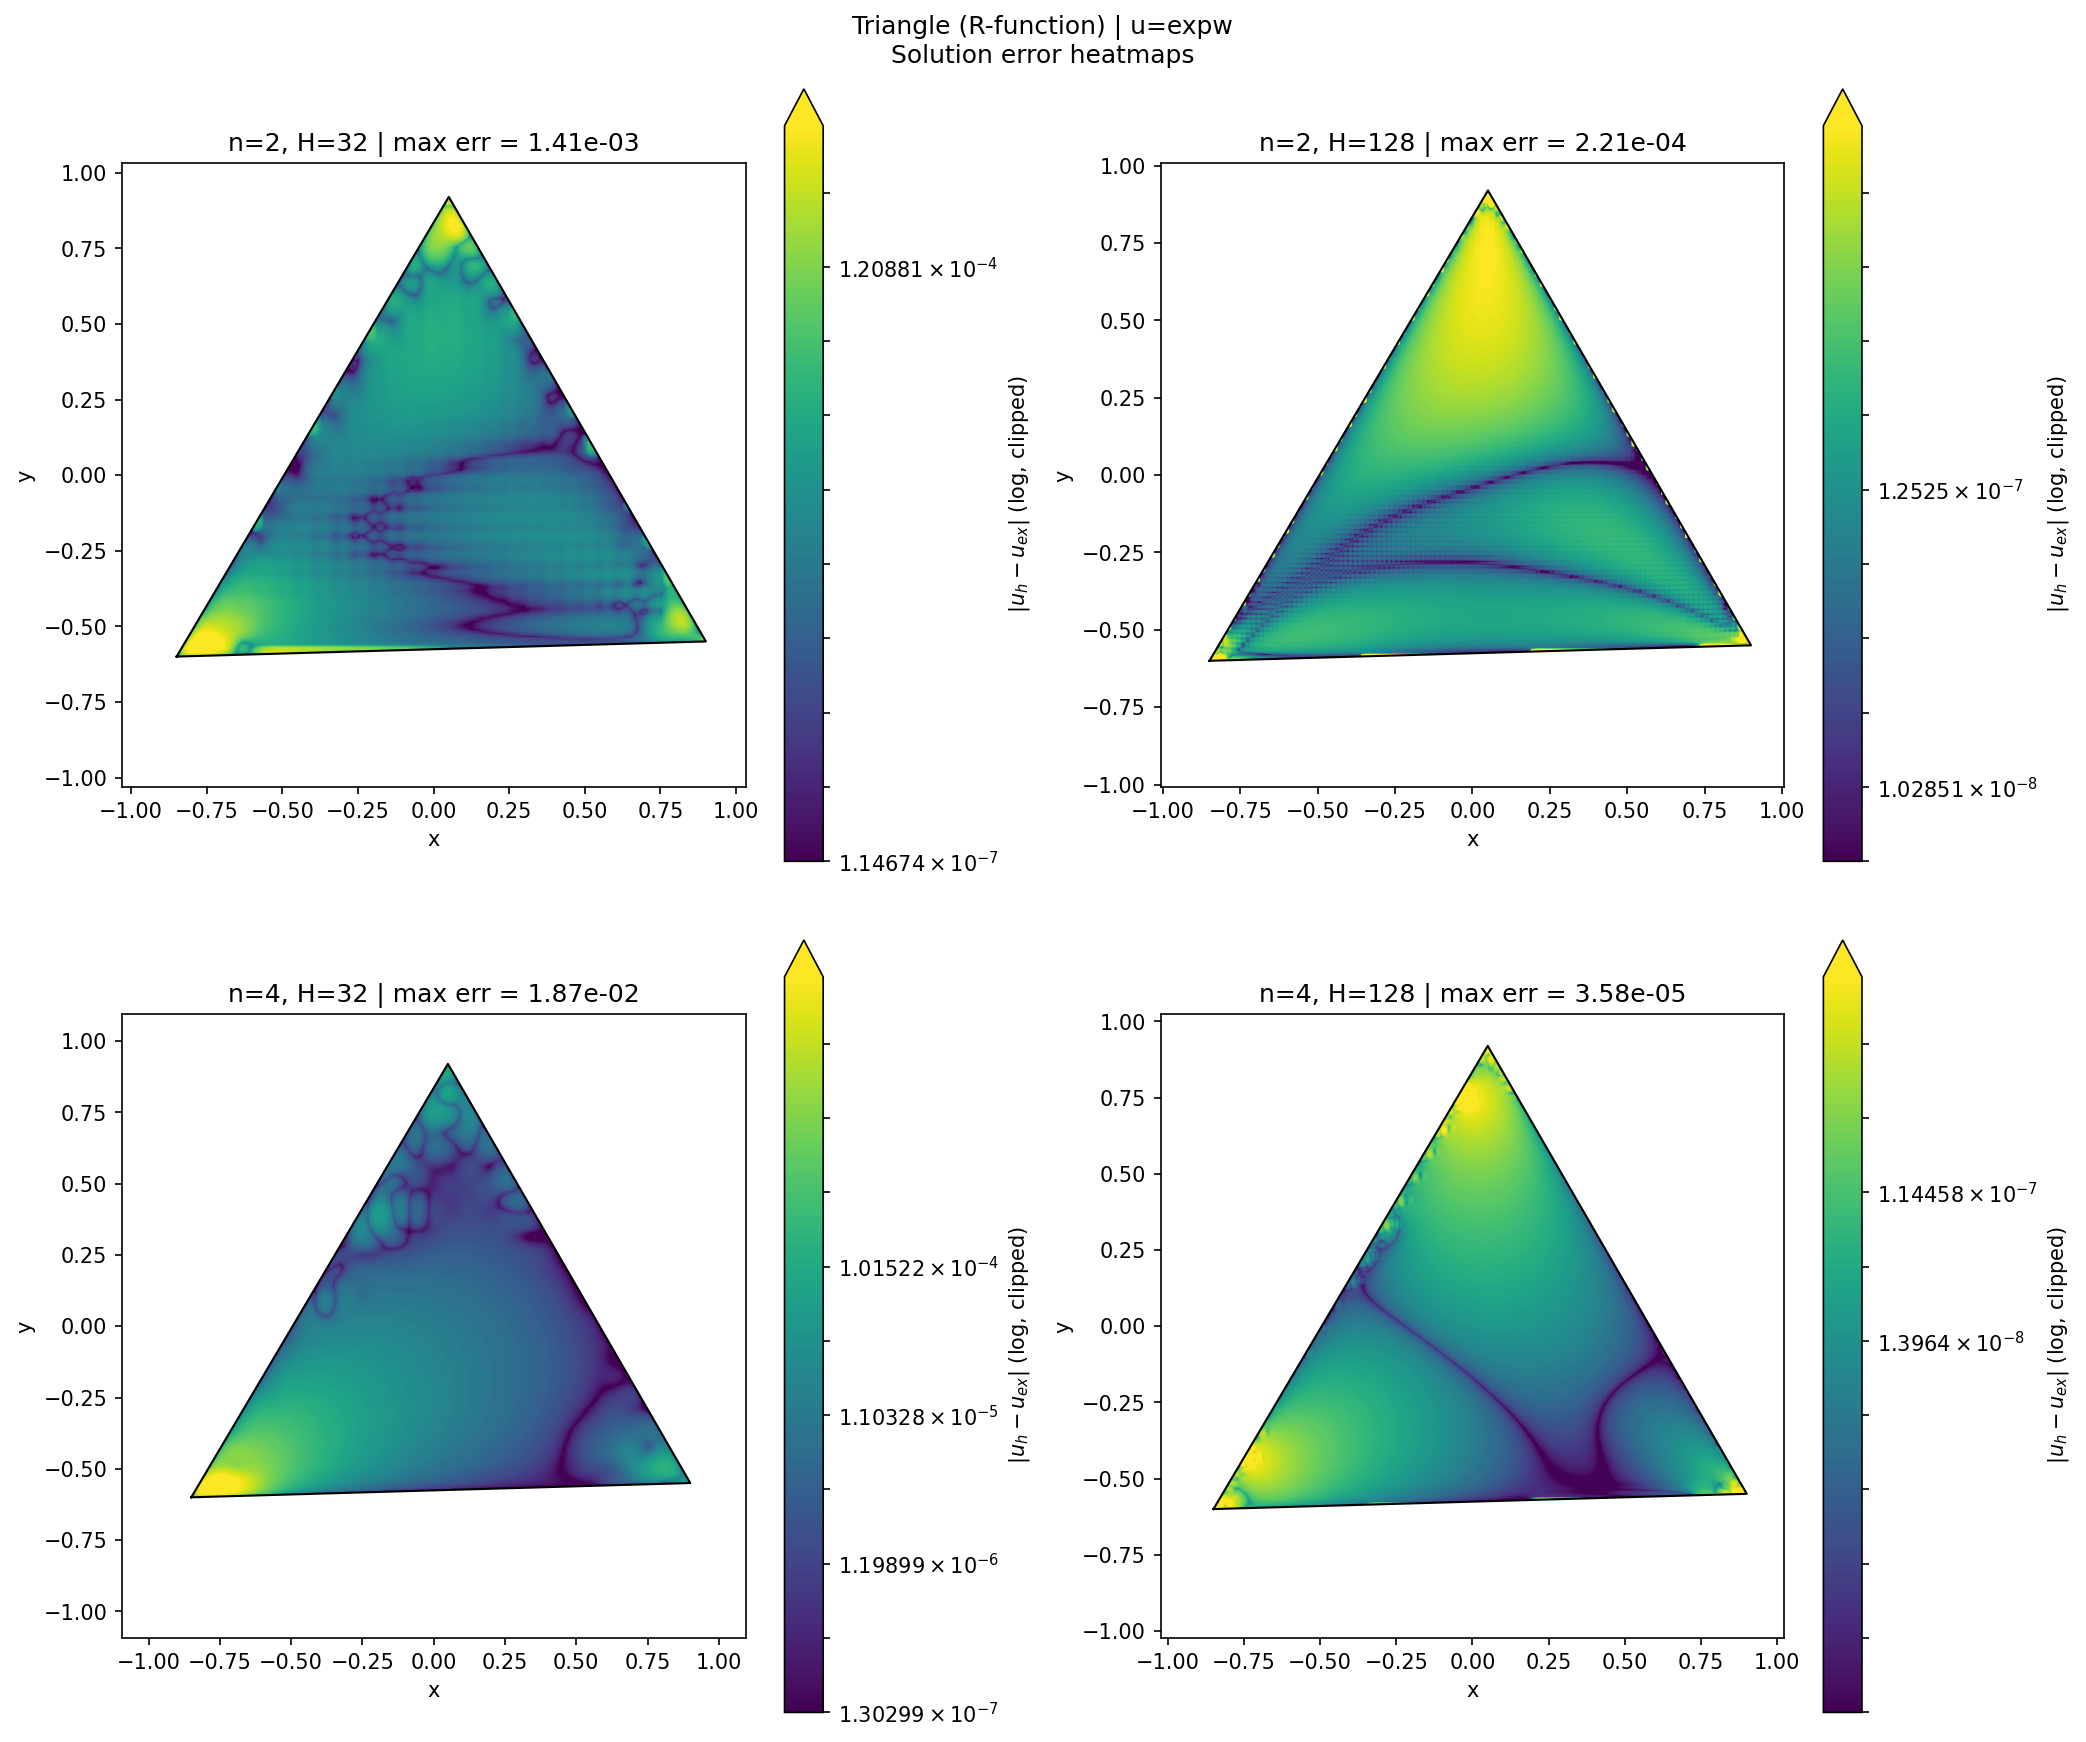

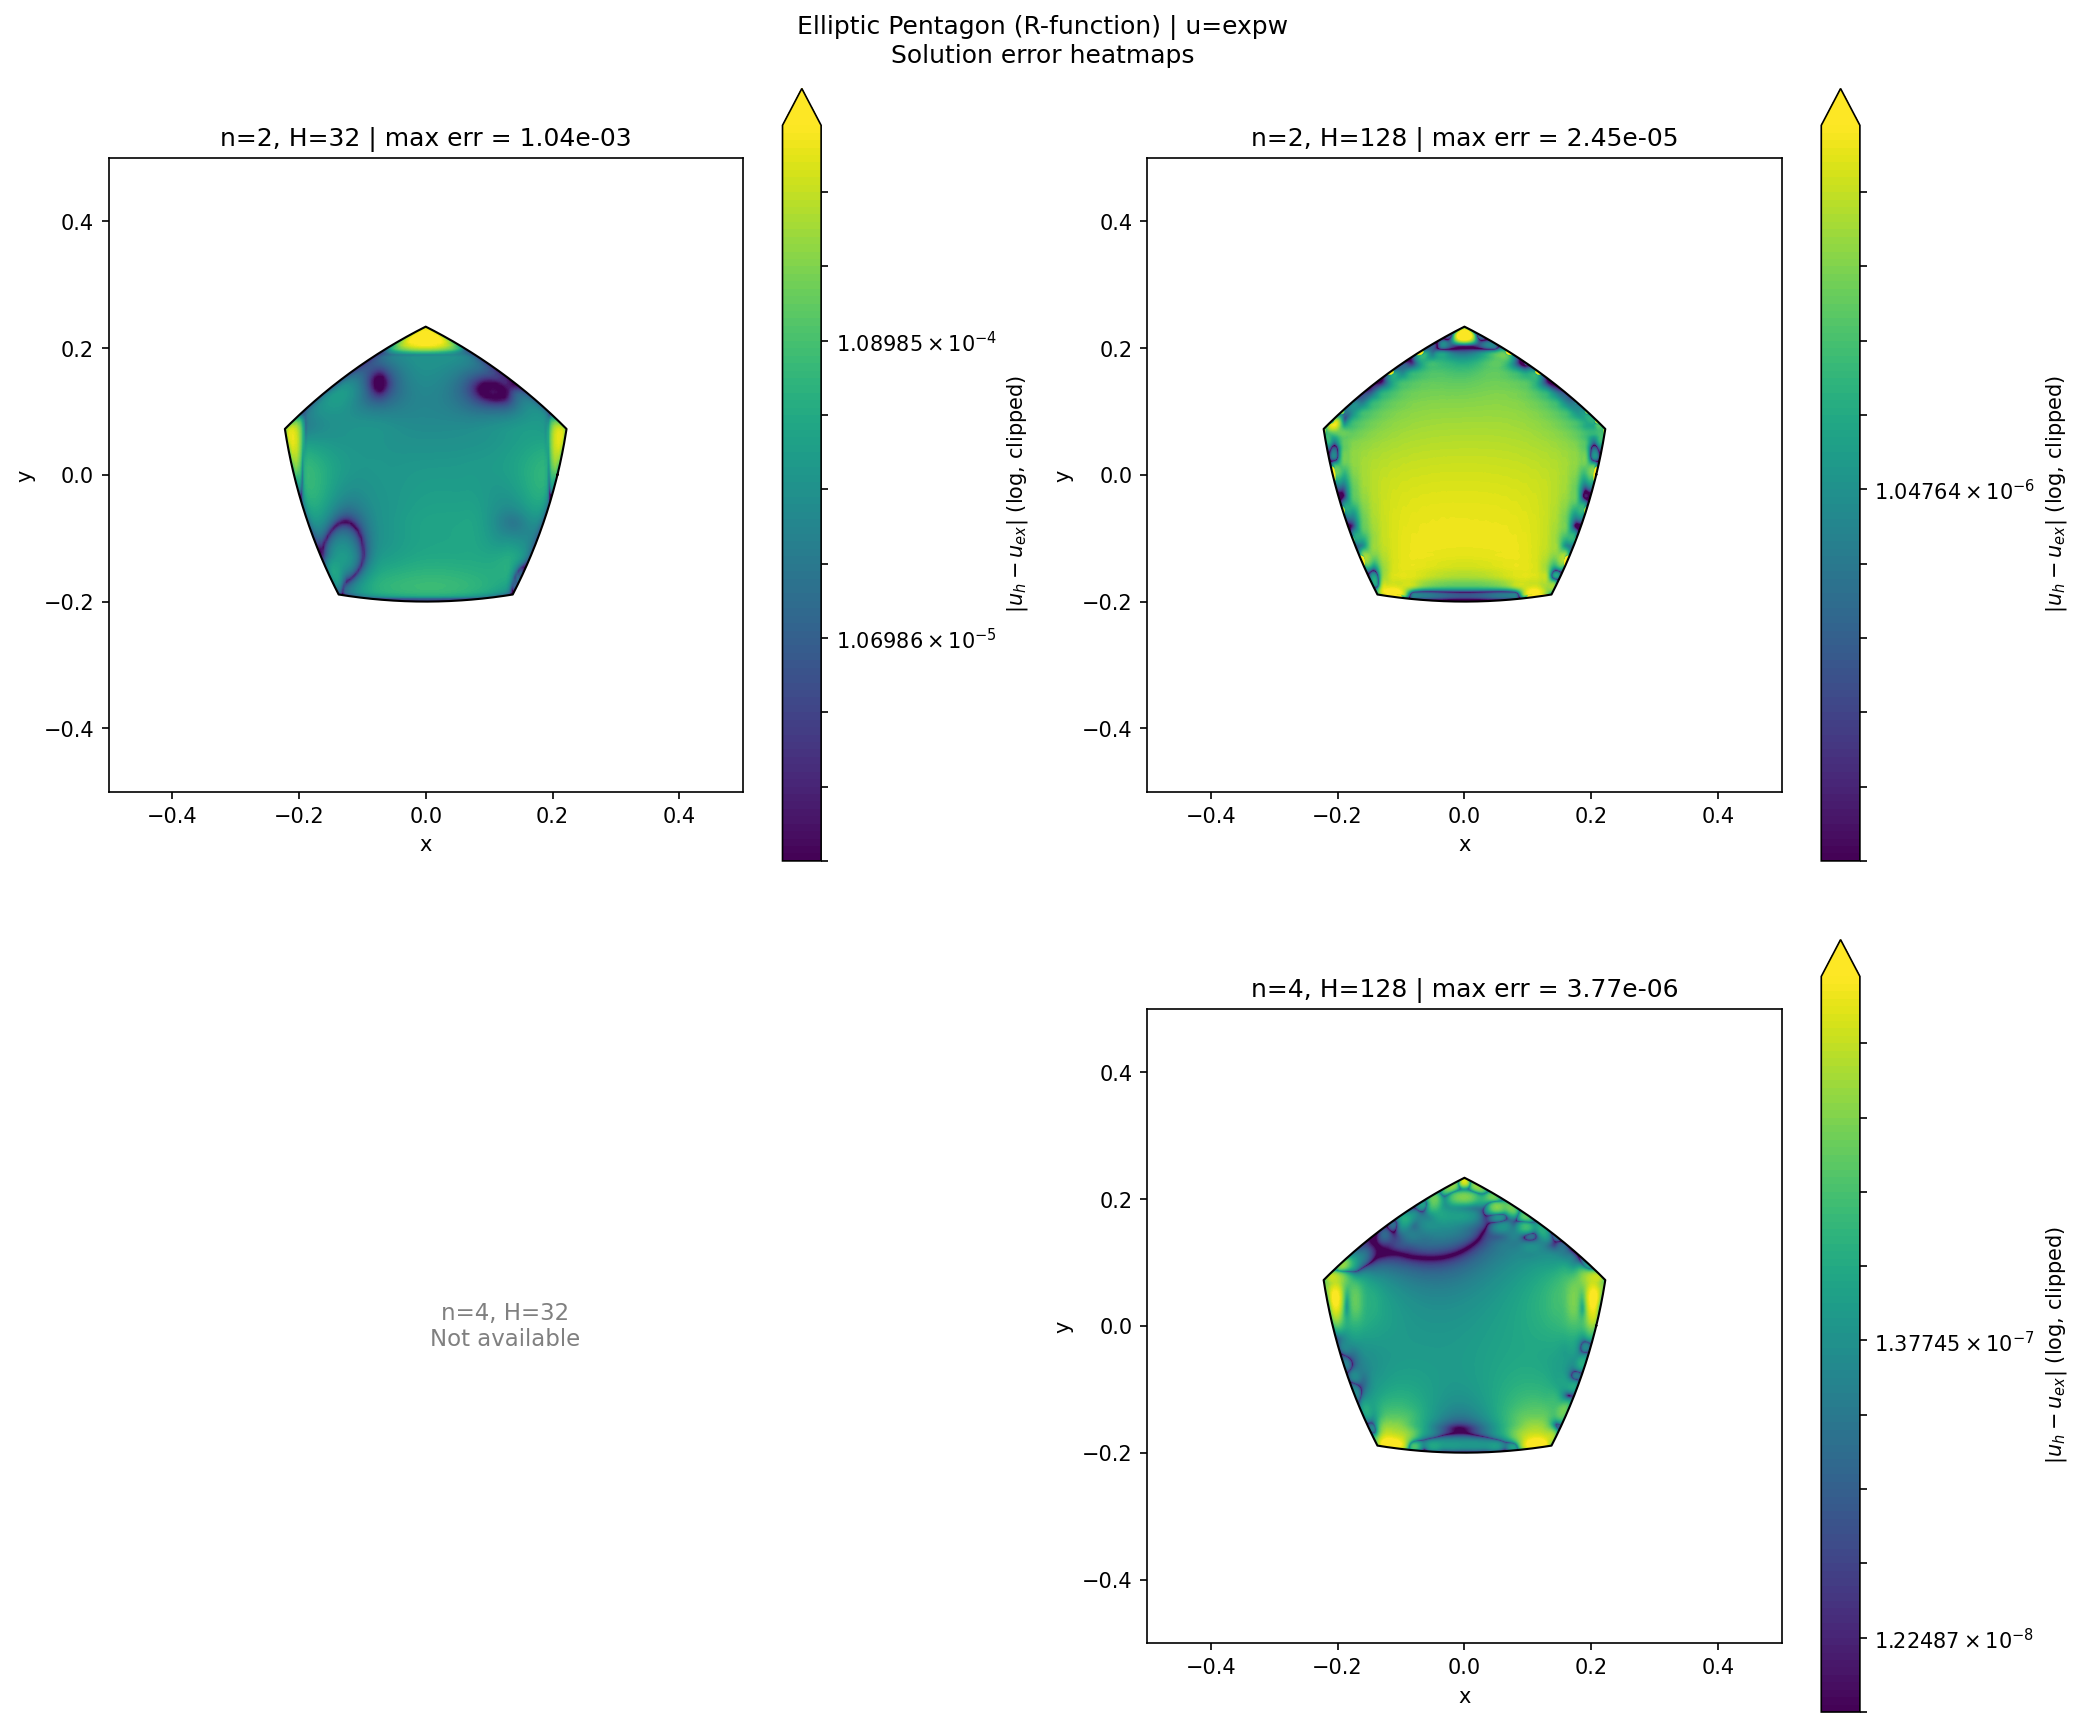

In [5]:
# ==========================================================================
# Solution error heatmaps for each geometry at all (n, H) combinations
# ==========================================================================

from matplotlib.patches import Polygon
import matplotlib.colors as mcolors

for gv in GEOMS:
    nrows = len(DEGREES)
    ncols = len(HS_ALL)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]
    boundary_pts = get_boundary_pts(gv)
    bp = boundary_pts

    for n_idx, n_show in enumerate(DEGREES):
        for col_idx, H_show in enumerate(HS_ALL):
            ax = axes[n_idx, col_idx]
            key = (gv.name, n_show, H_show)
            if key not in all_results:
                ax.axis("off")
                ax.text(0.5, 0.5, f"n={n_show}, H={H_show}\nNot available",
                        transform=ax.transAxes, ha="center", va="center",
                        fontsize=11, color="gray")
                continue
            res = all_results[key]

            # Fine-grid evaluation via B-spline reconstruction
            xP, yP = res["xP"], res["yP"]

            # For elliptic pentagon, use smaller domain [-0.5, 0.5]
            if "Elliptic" in gv.name:
                x1d = np.linspace(-0.5, 0.5, xP.shape[1] * PLOT_UPSAMPLE)
                y1d = np.linspace(-0.5, 0.5, xP.shape[0] * PLOT_UPSAMPLE)
            else:
                x1d = np.linspace(float(np.min(xP)), float(np.max(xP)),
                                  xP.shape[1] * PLOT_UPSAMPLE)
                y1d = np.linspace(float(np.min(yP)), float(np.max(yP)),
                                  xP.shape[0] * PLOT_UPSAMPLE)

            xPu, yPu = np.meshgrid(x1d, y1d)
            Uh_u = colloc.reconstruct_collocation_at_points(
                xPu.ravel(), yPu.ravel(), res["recon_info"], res["wfct_phys"]
            ).reshape(xPu.shape)
            w_u, *_ = res["wfct_phys"](xPu, yPu)
            Uex_u = res["u_exact_phys"](xPu, yPu)
            err_u = np.abs(Uh_u - Uex_u)
            inside_u = w_u > 0

            inside_vals = err_u[inside_u]
            if inside_vals.size:
                emax = float(np.max(inside_vals))
                vmin = float(np.quantile(inside_vals, 0.02))
                vmax = float(np.quantile(inside_vals, 0.995))
                vmin = max(vmin, 1e-14)
                vmax = max(vmax, vmin * 1.01)
            else:
                emax = 1e-10
                vmin, vmax = 1e-14, 1e-10

            # Robust smooth field: clip outliers, keep outside at vmin
            err_plot = np.where(inside_u, np.clip(err_u, vmin, vmax), vmin)
            levels = np.geomspace(vmin, vmax, CONTOUR_LEVELS)
            norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

            # Plot and clip to exact boundary (without deprecated cf.collections)
            before_n = len(ax.collections)
            im = ax.contourf(xPu, yPu, err_plot, levels=levels, norm=norm, extend="max")
            clip_patch = Polygon(bp, closed=True, transform=ax.transData,
                                 facecolor="none", edgecolor="none")
            ax.add_patch(clip_patch)
            for coll in ax.collections[before_n:]:
                coll.set_clip_path(clip_patch)

            fig.colorbar(im, ax=ax, label=r"$|u_h-u_{ex}|$ (log, clipped)")
            ax.plot(np.append(bp[:, 0], bp[0, 0]),
                    np.append(bp[:, 1], bp[0, 1]), 'k-', linewidth=1.0)
            ax.set_aspect("equal", adjustable="box")
            ax.set_title(f"n={n_show}, H={H_show} | max err = {emax:.2e}")
            ax.set_xlabel("x"); ax.set_ylabel("y")

    fig.suptitle(f"{gv.name} | u={U_EXACT_TYPE}\nSolution error heatmaps", fontsize=12)
    fig.tight_layout()
    plt.show()


### 2.2 Derivative Errors: Gradient Norm and Hessian Diagonal Norm

Derivative errors are computed analytically via B-spline differentiation (not finite differences).
We show the **gradient error norm** $\|\nabla u_h - \nabla u_{\text{ex}}\|$ and the **Hessian diagonal error norm** $\sqrt{(u_{xx,h}-u_{xx,\text{ex}})^2 + (u_{yy,h}-u_{yy,\text{ex}})^2}$.

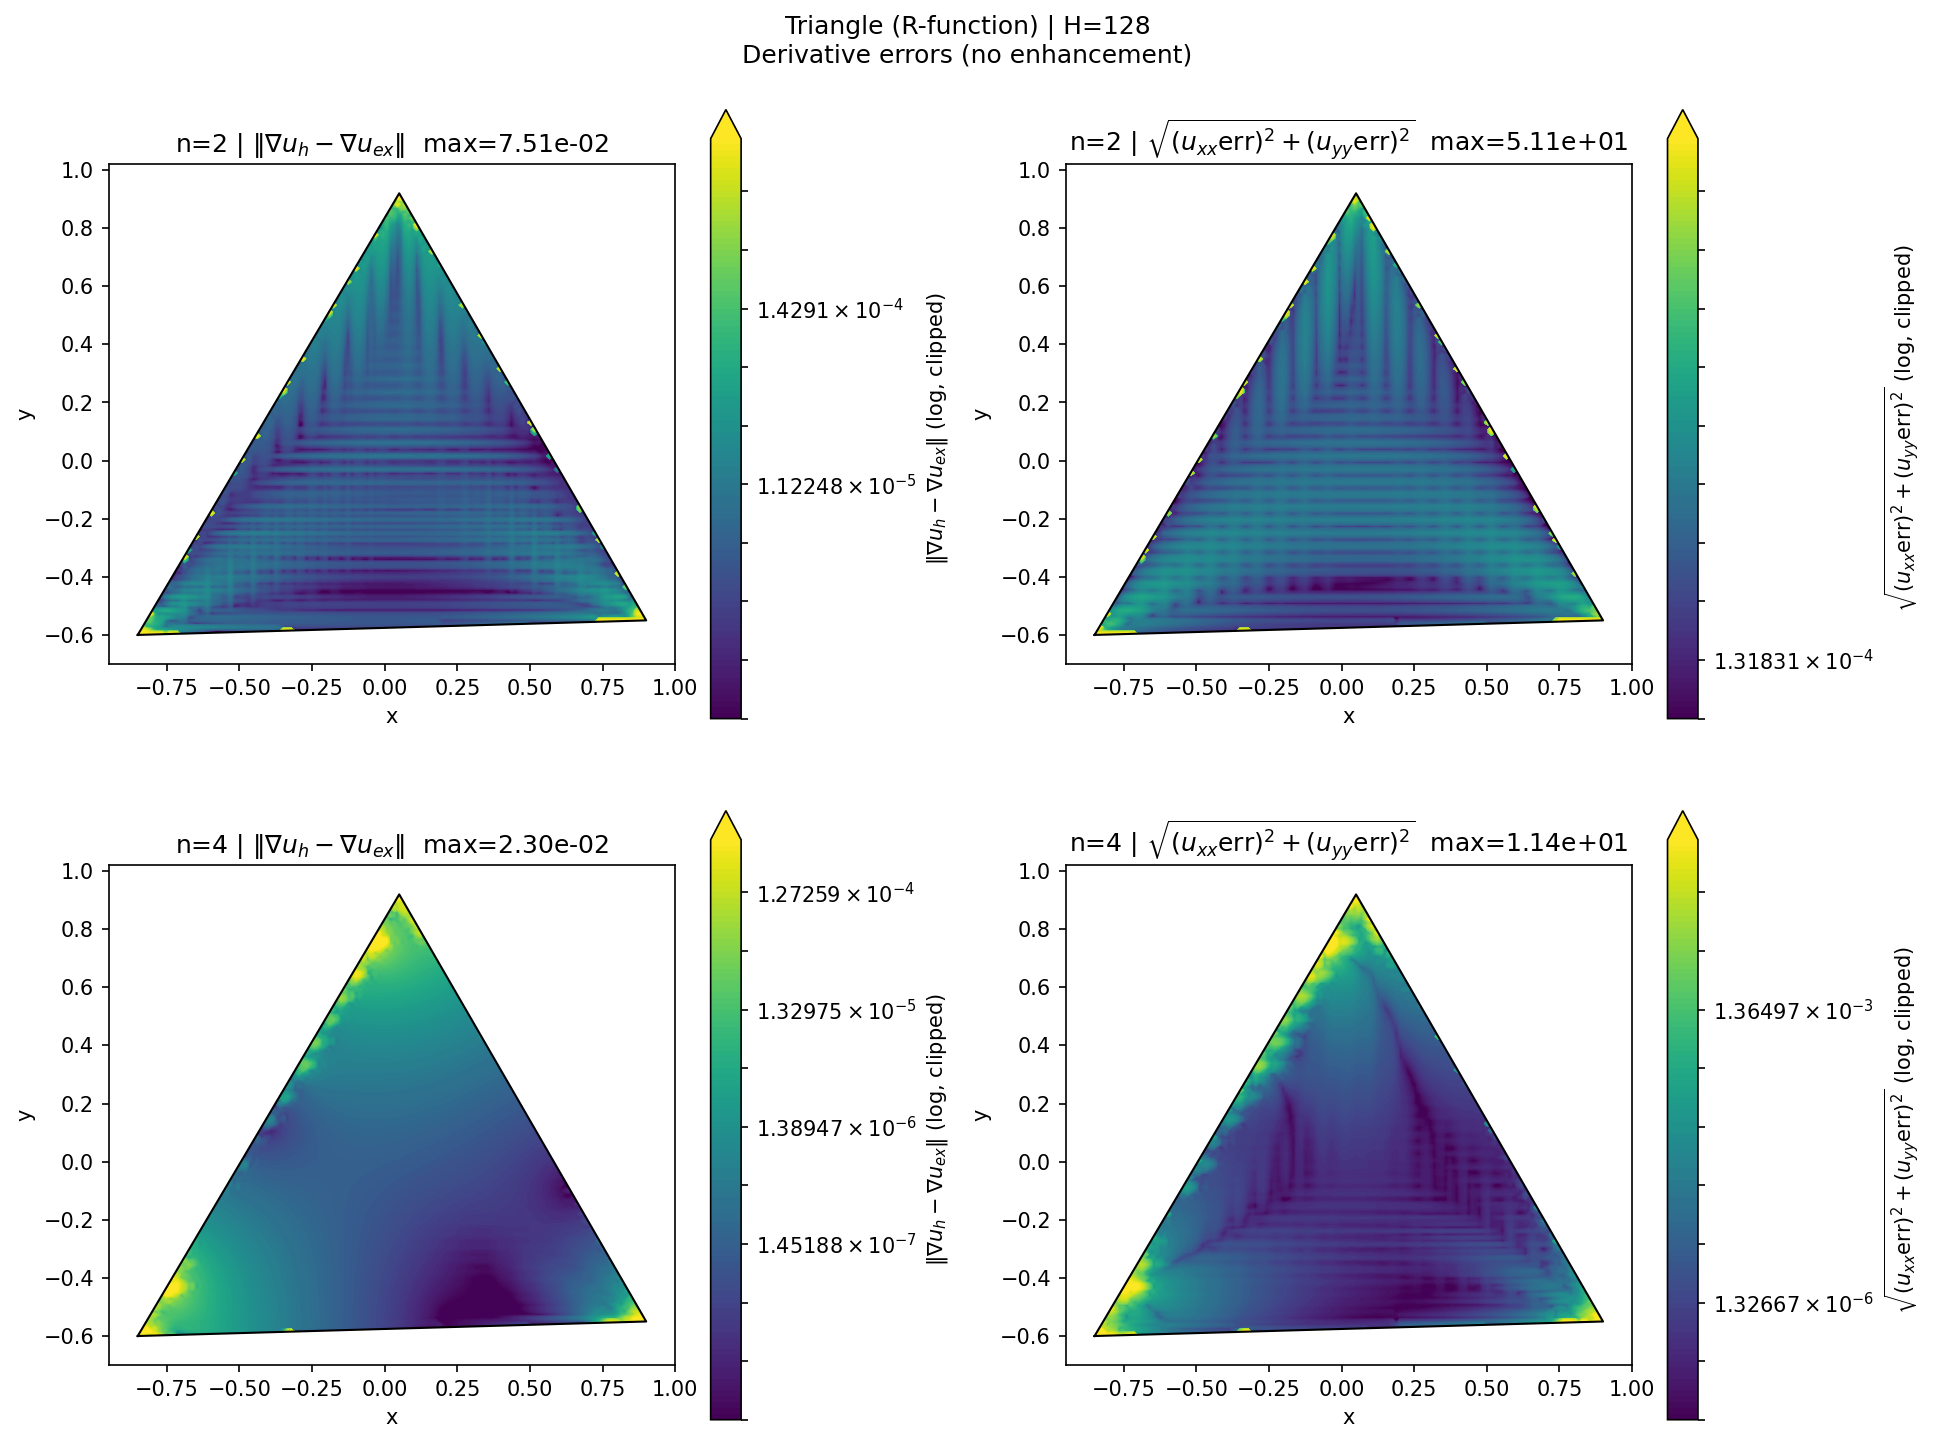

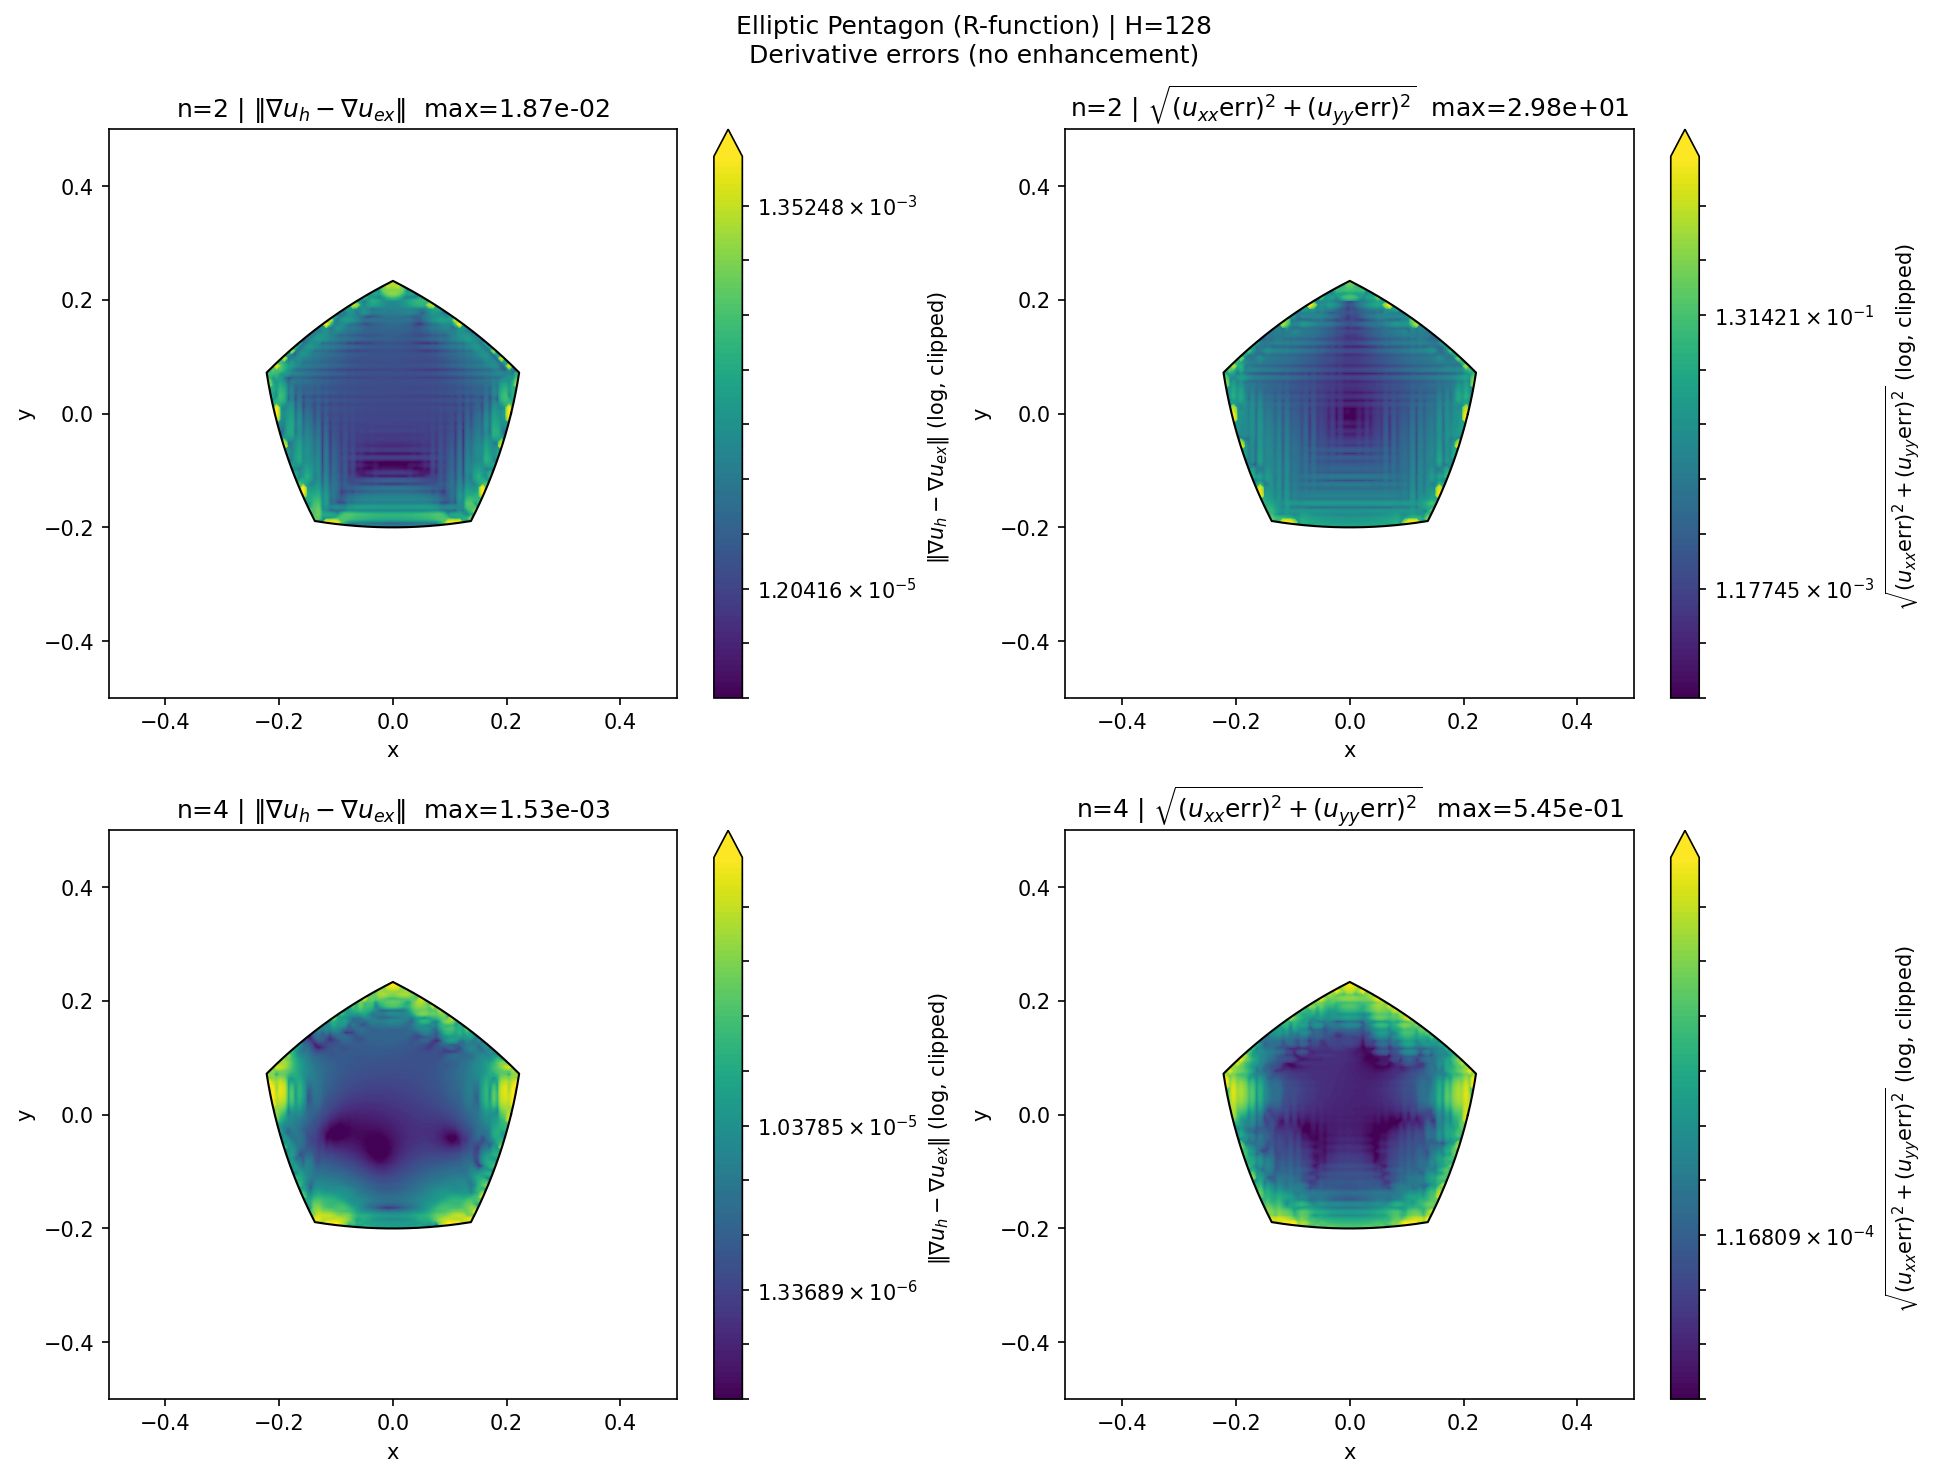

In [6]:
# ==========================================================================
# Derivative errors for each geometry and each degree at highest resolution
# ==========================================================================

import matplotlib.colors as mcolors

GRID_RES = 150
H_d = HS_ALL[-1]

for gv in GEOMS:
    boundary_pts = get_boundary_pts(gv)
    bp = boundary_pts

    # Match viewport style with solution heatmaps
    if "Elliptic" in gv.name:
        xmin_v, xmax_v = -0.5, 0.5
        ymin_v, ymax_v = -0.5, 0.5
    else:
        xmin_v = float(bp[:, 0].min()) - 0.1
        xmax_v = float(bp[:, 0].max()) + 0.1
        ymin_v = float(bp[:, 1].min()) - 0.1
        ymax_v = float(bp[:, 1].max()) + 0.1

    gx = np.linspace(xmin_v, xmax_v, GRID_RES)
    gy = np.linspace(ymin_v, ymax_v, GRID_RES)
    GX, GY = np.meshgrid(gx, gy)
    flat_x, flat_y = GX.ravel(), GY.ravel()

    fig, axes = plt.subplots(len(DEGREES), 2, figsize=(13, 5 * len(DEGREES)))
    if len(DEGREES) == 1:
        axes = axes[np.newaxis, :]

    for n_idx, n_d in enumerate(DEGREES):
        key = (gv.name, n_d, H_d)
        if key not in all_results:
            print(f"Skipping {gv.name} n={n_d} H={H_d} (not available)")
            for col in range(2):
                axes[n_idx, col].axis("off")
                axes[n_idx, col].text(0.5, 0.5, f"n={n_d}, H={H_d}\nNot available",
                                      transform=axes[n_idx, col].transAxes,
                                      ha="center", va="center", color="gray")
            continue

        res = all_results[key]
        wfct_phys = res["wfct_phys"]
        recon_info = res["recon_info"]

        u_h, ux_h, uy_h, uxx_h, uyy_h = colloc.reconstruct_collocation_hessian_diag(
            flat_x, flat_y, recon_info, wfct_phys)
        ux_ex, uy_ex, uxx_ex, uyy_ex = compute_exact_derivatives(
            wfct_phys, flat_x, flat_y, U_EXACT_TYPE)

        w_vals, *_ = wfct_phys(flat_x, flat_y)
        w_vals = np.asarray(w_vals).ravel()
        inside = w_vals > 0
        valid_grid = inside.reshape(GX.shape)

        grad_err = np.sqrt((ux_h - ux_ex)**2 + (uy_h - uy_ex)**2)
        hess_err = np.sqrt((uxx_h - uxx_ex)**2 + (uyy_h - uyy_ex)**2)

        deriv_data = [
            (r"$\|\nabla u_h - \nabla u_{ex}\|$", grad_err),
            (r"$\sqrt{(u_{xx}\mathrm{err})^2+(u_{yy}\mathrm{err})^2}$", hess_err),
        ]

        for col_idx, (latex_label, err_flat) in enumerate(deriv_data):
            ax = axes[n_idx, col_idx]
            err_grid = err_flat.reshape(GX.shape)

            ei = err_flat[inside]
            if ei.size:
                emax = float(np.max(ei))
                vmin = float(np.quantile(ei, 0.02))
                vmax = float(np.quantile(ei, 0.995))
                vmin = max(vmin, 1e-14)
                vmax = max(vmax, vmin * 1.01)
            else:
                emax = 1e-10
                vmin, vmax = 1e-14, 1e-10

            # Robust smooth field: clip outliers, keep outside at vmin
            err_grid_plot = np.where(valid_grid, np.clip(err_grid, vmin, vmax), vmin)
            levels = np.geomspace(vmin, vmax, 100)
            norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

            # Plot and clip to exact boundary (without deprecated cf.collections)
            before_n = len(ax.collections)
            im = ax.contourf(GX, GY, err_grid_plot, levels=levels, norm=norm, extend="max")
            clip_patch = Polygon(bp, closed=True, transform=ax.transData,
                                 facecolor="none", edgecolor="none")
            ax.add_patch(clip_patch)
            for coll in ax.collections[before_n:]:
                coll.set_clip_path(clip_patch)

            fig.colorbar(im, ax=ax, label=f"{latex_label} (log, clipped)")
            ax.plot(np.append(bp[:, 0], bp[0, 0]),
                    np.append(bp[:, 1], bp[0, 1]), 'k-', linewidth=1.0)
            ax.set_aspect("equal", adjustable="box")
            ax.set_title(f"n={n_d} | {latex_label}  max={emax:.2e}")
            ax.set_xlabel("x"); ax.set_ylabel("y")

    fig.suptitle(f"{gv.name} | H={H_d}\nDerivative errors (no enhancement)", fontsize=12)
    fig.tight_layout()
    plt.show()


### 2.3 Near-Boundary Error Localization

Errors are binned by distance from the boundary (SDF). This reveals the characteristic **near-boundary error concentration** in immersed methods.

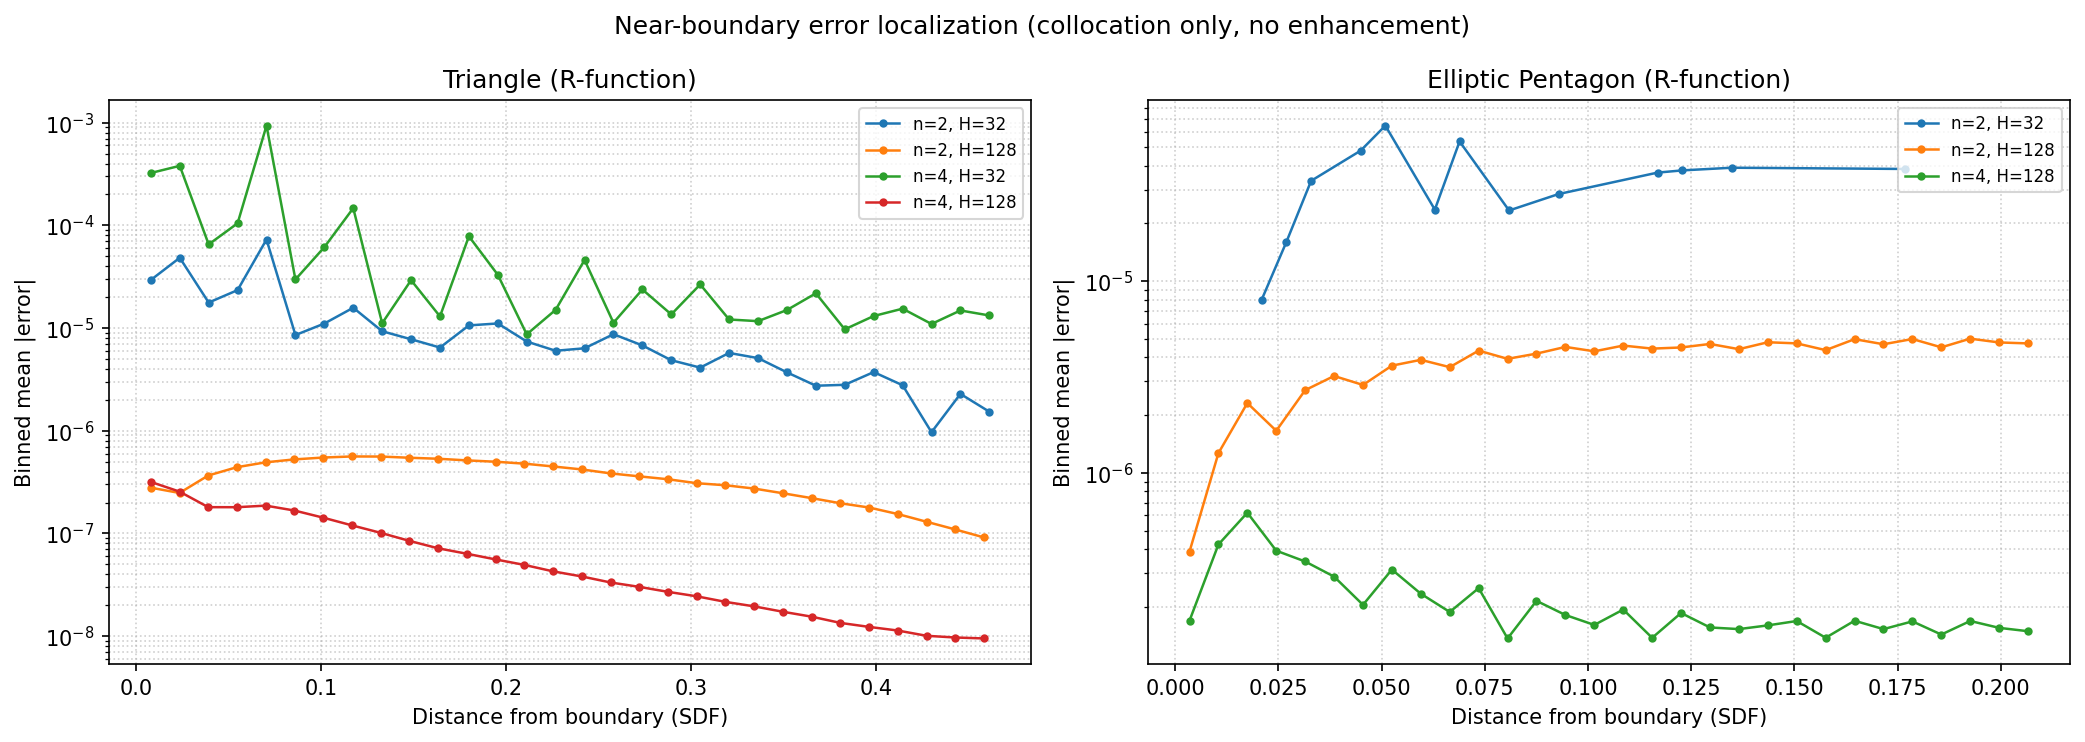

In [7]:
# ==========================================================================
# Near-boundary error binning for all resolutions
# ==========================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, gv in enumerate(GEOMS):
    ax = axes[idx]
    for n in DEGREES:
        for H in HS_ALL:
            key = (gv.name, n, H)
            if key not in all_results:
                continue
            res = all_results[key]
            if not res["bins"].empty:
                ax.plot(res["bins"]["w_mid"], res["bins"]["err_mean"],
                        marker="o", ms=3, lw=1.2, label=f"n={n}, H={H}")

    ax.set_yscale("log")
    ax.set_xlabel("Distance from boundary (SDF)")
    ax.set_ylabel("Binned mean |error|")
    ax.set_title(gv.name)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", ls=":", alpha=0.6)

fig.suptitle("Near-boundary error localization (collocation only, no enhancement)",
             fontsize=12)
fig.tight_layout()
plt.show()

## 3. Neural Enhancement

We now train SIREN networks to correct the near-boundary errors. The training uses the psi-weighted ansatz, which confines the correction to a narrow band around the boundary.

### Psi Weighting Function

$$\psi(x,y) = w(x,y) \cdot \varphi\!\left(\frac{\text{SDF}(x,y)}{\epsilon}\right), \quad \varphi(s) = \max(0, 1-s^2)^3$$

Properties:
- $\psi = 0$ at the boundary ($w = 0$)
- $\psi = 0$ in the interior ($\text{SDF} > \epsilon$)
- $\psi$ is $C^2$ everywhere
- The correction $\psi \cdot u_{\text{nn}}$ does not affect the Dirichlet BC

In [8]:
# ==========================================================================
# Neural Enhancement Helper Functions
# ==========================================================================

def compute_phi_and_derivs(s):
    """Polynomial compact-support cutoff: phi(s) = max(0, 1-s^2)^3."""
    s = np.asarray(s, dtype=np.float64)
    t = np.clip(1.0 - s**2, 0.0, None)
    active = t > 0
    phi = t**3
    phi_prime = np.zeros_like(s)
    phi_prime[active] = -6.0 * s[active] * (1.0 - s[active]**2)**2
    phi_dbl = np.zeros_like(s)
    phi_dbl[active] = -6.0 * (1.0 - s[active]**2) * (1.0 - 5.0 * s[active]**2)
    return phi, phi_prime, phi_dbl


def compute_sdf_and_grad_polygon(pts_x, pts_y, verts_np):
    """SDF, gradient for polygon. Second derivatives are zero (linear halfplanes)."""
    pts_x = np.asarray(pts_x, dtype=np.float64).ravel()
    pts_y = np.asarray(pts_y, dtype=np.float64).ravel()
    n_verts = len(verts_np)
    n_pts = len(pts_x)
    h_all = np.zeros((n_pts, n_verts), dtype=np.float64)
    nx_all = np.zeros(n_verts, dtype=np.float64)
    ny_all = np.zeros(n_verts, dtype=np.float64)
    for i in range(n_verts):
        v0 = verts_np[i]
        v1 = verts_np[(i + 1) % n_verts]
        ex = v1[0] - v0[0]
        ey = v1[1] - v0[1]
        length = np.sqrt(ex**2 + ey**2)
        nx_all[i] = -ey / length
        ny_all[i] = ex / length
        h_all[:, i] = nx_all[i] * (pts_x - v0[0]) + ny_all[i] * (pts_y - v0[1])
    j_min = np.argmin(h_all, axis=1)
    sdf = h_all[np.arange(n_pts), j_min]
    sdf_x = nx_all[j_min]
    sdf_y = ny_all[j_min]
    return sdf, sdf_x, sdf_y


def compute_algebraic_sdf_and_derivs(pts_x, pts_y, model):
    """SDF and derivs for elliptic domain (non-zero sdf_xx, sdf_yy)."""
    pts_x = np.asarray(pts_x, dtype=np.float64).ravel()
    pts_y = np.asarray(pts_y, dtype=np.float64).ravel()
    n_pts = len(pts_x)
    n_sides = model.n_sides
    F_all = np.zeros((n_pts, n_sides))
    Fx_all = np.zeros((n_pts, n_sides))
    Fy_all = np.zeros((n_pts, n_sides))
    Fxx_all = np.zeros(n_sides)
    Fyy_all = np.zeros(n_sides)
    for k in range(n_sides):
        alpha = model._angles_np[k]
        cx, cy = model._centers_np[k]
        a, b = model._semi_a_np[k], model._semi_b_np[k]
        sa, ca = np.sin(alpha), np.cos(alpha)
        dx = pts_x - cx
        dy = pts_y - cy
        pt = -sa * dx + ca * dy
        pr = ca * dx + sa * dy
        F_all[:, k] = 1.0 - pt**2/a**2 - pr**2/b**2
        Fx_all[:, k] = 2*sa*pt/a**2 - 2*ca*pr/b**2
        Fy_all[:, k] = -2*ca*pt/a**2 - 2*sa*pr/b**2
        Fxx_all[k] = -2*sa**2/a**2 - 2*ca**2/b**2
        Fyy_all[k] = -2*ca**2/a**2 - 2*sa**2/b**2
    j_min = np.argmin(F_all, axis=1)
    idx = np.arange(n_pts)
    return (F_all[idx, j_min], Fx_all[idx, j_min], Fy_all[idx, j_min],
            Fxx_all[j_min], Fyy_all[j_min])


def compute_psi_all(pts_x, pts_y, gv, wfct_phys, eps_band):
    """Compute psi = w * phi(SDF/eps) and its derivatives for either geometry type."""
    w, wx, wy, wxx, wyy = wfct_phys(pts_x, pts_y)
    w = np.asarray(w, dtype=np.float64).ravel()
    wx = np.asarray(wx, dtype=np.float64).ravel()
    wy = np.asarray(wy, dtype=np.float64).ravel()
    wxx = np.asarray(wxx, dtype=np.float64).ravel()
    wyy = np.asarray(wyy, dtype=np.float64).ravel()

    if gv.geom_type == 'polygon':
        sdf, sdf_x, sdf_y = compute_sdf_and_grad_polygon(pts_x, pts_y, gv.model._vertices_np)
        sdf_xx, sdf_yy = 0.0, 0.0  # linear halfplanes
    else:
        sdf, sdf_x, sdf_y, sdf_xx, sdf_yy = compute_algebraic_sdf_and_derivs(
            pts_x, pts_y, gv.model)

    s = sdf / eps_band
    sx = sdf_x / eps_band
    sy = sdf_y / eps_band
    sxx = sdf_xx / eps_band if not np.isscalar(sdf_xx) or sdf_xx != 0.0 else 0.0
    syy = sdf_yy / eps_band if not np.isscalar(sdf_yy) or sdf_yy != 0.0 else 0.0

    phi, phi_p, phi_pp = compute_phi_and_derivs(s)
    psi = w * phi
    psi_x = wx * phi + w * phi_p * sx
    psi_y = wy * phi + w * phi_p * sy
    psi_xx = wxx * phi + 2.0 * wx * phi_p * sx + w * (phi_pp * sx**2 + phi_p * sxx)
    psi_yy = wyy * phi + 2.0 * wy * phi_p * sy + w * (phi_pp * sy**2 + phi_p * syy)
    return psi, psi_x, psi_y, psi_xx, psi_yy


def sample_near_boundary(gv, n_points, eps_band, rng=None):
    """Sample near-boundary interior points for either geometry type."""
    if rng is None:
        rng = np.random.default_rng(42)
    bp = get_boundary_pts(gv)
    xmin, xmax = float(bp[:, 0].min()) - 0.1, float(bp[:, 0].max()) + 0.1
    ymin, ymax = float(bp[:, 1].min()) - 0.1, float(bp[:, 1].max()) + 0.1
    pts_x, pts_y = [], []
    collected = 0
    while collected < n_points:
        batch = max(n_points * 5, 10000)
        rx = rng.uniform(xmin, xmax, size=batch)
        ry = rng.uniform(ymin, ymax, size=batch)
        sdf = compute_sdf(rx, ry, gv)
        mask = (sdf > 0) & (sdf < eps_band)
        pts_x.append(rx[mask])
        pts_y.append(ry[mask])
        collected += mask.sum()
    return np.concatenate(pts_x)[:n_points], np.concatenate(pts_y)[:n_points]


def sample_interior(gv, n_points, seed=77):
    """Sample uniformly inside the domain."""
    rng = np.random.default_rng(seed)
    bp = get_boundary_pts(gv)
    xmin, xmax = float(bp[:, 0].min()) - 0.05, float(bp[:, 0].max()) + 0.05
    ymin, ymax = float(bp[:, 1].min()) - 0.05, float(bp[:, 1].max()) + 0.05
    pts_x, pts_y = [], []
    collected = 0
    while collected < n_points:
        batch = max(n_points * 3, 5000)
        rx = rng.uniform(xmin, xmax, size=batch)
        ry = rng.uniform(ymin, ymax, size=batch)
        inside_mask = point_inside(rx, ry, gv)
        pts_x.append(rx[inside_mask])
        pts_y.append(ry[inside_mask])
        collected += inside_mask.sum()
    return np.concatenate(pts_x)[:n_points], np.concatenate(pts_y)[:n_points]


def compute_input_distances(crd, gv):
    """Compute NN input features (differentiable w.r.t. crd)."""
    if gv.geom_type == 'polygon':
        hp = geom._halfplane_distances(crd, crd.new_tensor(gv.model._vertices_np))
        return torch.stack(hp, dim=-1)
    else:
        return torch.stack(gv.model._algebraic_distances_torch(crd), dim=-1)


def get_n_inputs(gv):
    """Number of input features for the NN."""
    if gv.geom_type == 'polygon':
        return gv.model._vertices_np.shape[0]
    else:
        return gv.model.n_sides


print("Enhancement helpers defined.")

Enhancement helpers defined.


In [9]:
# ==========================================================================
# Train SIREN Enhancement for both geometries at both resolutions
# ==========================================================================

def train_siren_enhancement(gv, res, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE,
                            pool_size=POOL_SIZE, eps_band=EPS_BAND,
                            omega_first=20.0, omega_hidden=20.0, lr=1e-5):
    """Train SIREN enhancement for given collocation result. Returns model, loss_hist, train_time."""
    recon_info = res["recon_info"]
    wfct_phys = res["wfct_phys"]

    n_in = get_n_inputs(gv)
    model_nn = network_defs.Siren(
        architecture=[n_in, 256, 256, 256, 1], outermost_linear=True,
        first_omega_0=omega_first, hidden_omega_0=omega_hidden
    ).double()
    optimizer = torch.optim.Adam(model_nn.parameters(), lr=lr)

    # Sample near-boundary pool
    print(f"  Sampling {pool_size} near-boundary points...")
    pool_x, pool_y = sample_near_boundary(gv, pool_size, eps_band)

    # Pre-compute collocation Hessian at pool
    print(f"  Pre-computing collocation Hessian...")
    _, _, _, pool_uxx, pool_uyy = colloc.reconstruct_collocation_hessian_diag(
        pool_x, pool_y, recon_info, wfct_phys)

    # Pre-compute weight function
    pool_w, pool_wx, pool_wy, pool_wxx, pool_wyy = wfct_phys(pool_x, pool_y)
    pool_w = np.asarray(pool_w).ravel()
    pool_uxx = np.asarray(pool_uxx).ravel()
    pool_uyy = np.asarray(pool_uyy).ravel()
    pool_wx = np.asarray(pool_wx).ravel()
    pool_wy = np.asarray(pool_wy).ravel()
    pool_wxx = np.asarray(pool_wxx).ravel()
    pool_wyy = np.asarray(pool_wyy).ravel()

    # Compute f
    if U_EXACT_TYPE == "expw":
        ew = np.exp(pool_w)
        pool_f = -(ew * (pool_wx**2 + pool_wy**2 + pool_wxx + pool_wyy))
    else:
        pool_f = -(2.0 * (pool_wx**2 + pool_wy**2) + 2.0 * pool_w * (pool_wxx + pool_wyy))

    pool_colloc_residual = (pool_uxx + pool_uyy + pool_f)

    # Pre-compute psi
    print(f"  Pre-computing psi...")
    pool_psi, pool_psi_x, pool_psi_y, pool_psi_xx, pool_psi_yy = compute_psi_all(
        pool_x, pool_y, gv, wfct_phys, eps_band)

    # Loss weights (SDF-proximity)
    pool_sdf = compute_sdf(pool_x, pool_y, gv)
    WEIGHT_DELTA = eps_band * 0.05
    pool_loss_weight = eps_band / (pool_sdf + WEIGHT_DELTA)
    pool_loss_weight = pool_loss_weight / pool_loss_weight.mean()

    # Training
    loss_history = []
    rng_train = np.random.default_rng(123)
    t0 = time.time()

    for epoch in range(num_epochs):
        idx = rng_train.choice(pool_size, size=batch_size, replace=False)
        bx, by = pool_x[idx], pool_y[idx]
        colloc_residual_t = torch.tensor(pool_colloc_residual[idx], dtype=torch.float64)

        crd = torch.tensor(np.stack([bx, by], axis=-1), dtype=torch.float64, requires_grad=True)
        dists = compute_input_distances(crd, gv)
        u_nn = model_nn(dists).squeeze()

        grad_u_nn = torch.autograd.grad(
            u_nn, crd, grad_outputs=torch.ones_like(u_nn),
            create_graph=True, retain_graph=True)[0]
        u_nn_x, u_nn_y = grad_u_nn[:, 0], grad_u_nn[:, 1]

        u_nn_xx = torch.autograd.grad(
            u_nn_x, crd, grad_outputs=torch.ones_like(u_nn_x),
            create_graph=True, retain_graph=True)[0][:, 0]
        u_nn_yy = torch.autograd.grad(
            u_nn_y, crd, grad_outputs=torch.ones_like(u_nn_y),
            create_graph=True, retain_graph=True)[0][:, 1]

        #b_weight = torch.tensor(pool_loss_weight[idx], dtype=torch.float64)
        b_psi = torch.tensor(pool_psi[idx], dtype=torch.float64)
        b_psi_x = torch.tensor(pool_psi_x[idx], dtype=torch.float64)
        b_psi_y = torch.tensor(pool_psi_y[idx], dtype=torch.float64)
        b_psi_xx = torch.tensor(pool_psi_xx[idx], dtype=torch.float64)
        b_psi_yy = torch.tensor(pool_psi_yy[idx], dtype=torch.float64)

        laplacian_psi_unn = (
            (b_psi_xx + b_psi_yy) * u_nn
            + 2.0 * (b_psi_x * u_nn_x + b_psi_y * u_nn_y)
            + b_psi * (u_nn_xx + u_nn_yy)
        )

        total_residual = colloc_residual_t + laplacian_psi_unn
        loss = (total_residual ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
        if epoch % 100 == 0 or epoch == num_epochs - 1:
            print(f"    epoch {epoch:4d}  loss={loss.item():.6e}")

    train_time = time.time() - t0
    return model_nn, loss_history, train_time


print("Training function defined.")

Training function defined.


In [10]:
# ==========================================================================
# Train KAN Enhancement (for comparison)
# ==========================================================================

def train_kan_enhancement(gv, res, num_epochs=NUM_EPOCHS, batch_size=BATCH_SIZE,
                          pool_size=POOL_SIZE, eps_band=EPS_BAND,
                          grid_size=32, lr=1e-4, lam_smooth=1e-3):
    """Train KAN enhancement. Returns model, loss_hist, train_time."""
    recon_info = res["recon_info"]
    wfct_phys = res["wfct_phys"]

    n_in = get_n_inputs(gv)
    model_nn = network_defs.KAN(
        architecture=[n_in, 64, 64, 64, 1],
        grid_size=grid_size, grid_range=(0.0, 1.0),
        spline_order="cubic", use_base=True,
        base_activation="silu", spline_init_scale=1e-3,
    ).double()

    # Zero-init last layer
    with torch.no_grad():
        last = model_nn.net[-1]
        if hasattr(last, "spline_coeff"): last.spline_coeff.zero_()
        if hasattr(last, "spline_bias") and last.spline_bias is not None: last.spline_bias.zero_()
        if getattr(last, "use_base", False):
            if hasattr(last, "base_weight") and last.base_weight is not None: last.base_weight.zero_()
            if hasattr(last, "base_bias") and last.base_bias is not None: last.base_bias.zero_()

    optimizer = torch.optim.AdamW(model_nn.parameters(), lr=lr, weight_decay=1e-6)

    def kan_input_transform(dists):
        return dists / (dists + eps_band)

    def kan_spline_smoothness(model):
        reg = None
        for m in model.modules():
            if hasattr(m, "spline_coeff"):
                c = m.spline_coeff
                if c.shape[-1] >= 3:
                    d2 = c[..., 2:] - 2.0 * c[..., 1:-1] + c[..., :-2]
                    term = (d2 ** 2).mean()
                    reg = term if reg is None else (reg + term)
        return reg if reg is not None else torch.tensor(0.0, dtype=torch.float64)

    # Sample near-boundary pool
    print(f"  Sampling {pool_size} near-boundary points...")
    pool_x, pool_y = sample_near_boundary(gv, pool_size, eps_band)

    print(f"  Pre-computing collocation Hessian...")
    _, _, _, pool_uxx, pool_uyy = colloc.reconstruct_collocation_hessian_diag(
        pool_x, pool_y, recon_info, wfct_phys)

    pool_w, pool_wx, pool_wy, pool_wxx, pool_wyy = wfct_phys(pool_x, pool_y)
    pool_w = np.asarray(pool_w).ravel()
    pool_uxx = np.asarray(pool_uxx).ravel()
    pool_uyy = np.asarray(pool_uyy).ravel()
    pool_wx = np.asarray(pool_wx).ravel()
    pool_wy = np.asarray(pool_wy).ravel()
    pool_wxx = np.asarray(pool_wxx).ravel()
    pool_wyy = np.asarray(pool_wyy).ravel()

    if U_EXACT_TYPE == "expw":
        ew = np.exp(pool_w)
        pool_f = -(ew * (pool_wx**2 + pool_wy**2 + pool_wxx + pool_wyy))
    else:
        pool_f = -(2.0 * (pool_wx**2 + pool_wy**2) + 2.0 * pool_w * (pool_wxx + pool_wyy))

    pool_colloc_residual = pool_uxx + pool_uyy + pool_f

    print(f"  Pre-computing psi...")
    pool_psi, pool_psi_x, pool_psi_y, pool_psi_xx, pool_psi_yy = compute_psi_all(
        pool_x, pool_y, gv, wfct_phys, eps_band)

    pool_sdf = compute_sdf(pool_x, pool_y, gv)
    WEIGHT_DELTA = eps_band * 0.05
    pool_loss_weight = eps_band / (pool_sdf + WEIGHT_DELTA)
    pool_loss_weight = pool_loss_weight / pool_loss_weight.mean()

    loss_history = []
    rng_train = np.random.default_rng(123)
    t0 = time.time()

    for epoch in range(num_epochs):
        idx = rng_train.choice(pool_size, size=batch_size, replace=False)
        bx, by = pool_x[idx], pool_y[idx]
        colloc_residual_t = torch.tensor(pool_colloc_residual[idx], dtype=torch.float64)

        crd = torch.tensor(np.stack([bx, by], axis=-1), dtype=torch.float64, requires_grad=True)
        dists = compute_input_distances(crd, gv)
        dists_scaled = kan_input_transform(dists)
        u_nn = model_nn(dists_scaled).squeeze()

        grad_u_nn = torch.autograd.grad(
            u_nn, crd, grad_outputs=torch.ones_like(u_nn),
            create_graph=True, retain_graph=True)[0]
        u_nn_x, u_nn_y = grad_u_nn[:, 0], grad_u_nn[:, 1]

        u_nn_xx = torch.autograd.grad(
            u_nn_x, crd, grad_outputs=torch.ones_like(u_nn_x),
            create_graph=True, retain_graph=True)[0][:, 0]
        u_nn_yy = torch.autograd.grad(
            u_nn_y, crd, grad_outputs=torch.ones_like(u_nn_y),
            create_graph=True, retain_graph=True)[0][:, 1]

        b_weight = torch.tensor(pool_loss_weight[idx], dtype=torch.float64)
        b_psi = torch.tensor(pool_psi[idx], dtype=torch.float64)
        b_psi_x = torch.tensor(pool_psi_x[idx], dtype=torch.float64)
        b_psi_y = torch.tensor(pool_psi_y[idx], dtype=torch.float64)
        b_psi_xx = torch.tensor(pool_psi_xx[idx], dtype=torch.float64)
        b_psi_yy = torch.tensor(pool_psi_yy[idx], dtype=torch.float64)

        laplacian_psi_unn = (
            (b_psi_xx + b_psi_yy) * u_nn
            + 2.0 * (b_psi_x * u_nn_x + b_psi_y * u_nn_y)
            + b_psi * (u_nn_xx + u_nn_yy)
        )

        total_residual = colloc_residual_t + laplacian_psi_unn
        loss_res = (b_weight * total_residual ** 2).mean()
        loss_reg = kan_spline_smoothness(model_nn)
        loss = loss_res + lam_smooth * loss_reg

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_nn.parameters(), max_norm=1.0)
        optimizer.step()

        loss_history.append(loss.item())
        if epoch % 100 == 0 or epoch == num_epochs - 1:
            print(f"    epoch {epoch:4d}  loss={loss.item():.6e}")

    train_time = time.time() - t0
    return model_nn, loss_history, train_time, kan_input_transform


print("KAN training function defined.")

KAN training function defined.


In [11]:
# ==========================================================================
# Evaluation: compute corrected solution + derivative errors
# ==========================================================================

def evaluate_enhancement(gv, res, model_nn, eps_band=EPS_BAND,
                         n_eval=5000, input_transform=None):
    """Evaluate enhancement: returns dict with errors before/after."""
    wfct_phys = res["wfct_phys"]
    recon_info = res["recon_info"]
    u_exact_phys = res["u_exact_phys"]

    pts_x, pts_y = sample_interior(gv, n_eval)

    # Collocation solution + derivatives
    u_col, ux_col, uy_col, uxx_col, uyy_col = colloc.reconstruct_collocation_hessian_diag(
        pts_x, pts_y, recon_info, wfct_phys)
    u_ex = u_exact_phys(pts_x, pts_y)
    ux_ex, uy_ex, uxx_ex, uyy_ex = compute_exact_derivatives(
        wfct_phys, pts_x, pts_y, U_EXACT_TYPE)

    sdf = compute_sdf(pts_x, pts_y, gv)
    psi, psi_x, psi_y, psi_xx, psi_yy = compute_psi_all(
        pts_x, pts_y, gv, wfct_phys, eps_band)

    # NN forward + derivatives via autograd
    crd = torch.tensor(np.stack([pts_x, pts_y], axis=-1),
                       dtype=torch.float64, requires_grad=True)
    dists = compute_input_distances(crd, gv)
    if input_transform is not None:
        dists = input_transform(dists)
    u_nn = model_nn(dists).squeeze()

    grad_nn = torch.autograd.grad(u_nn.sum(), crd, create_graph=True, retain_graph=True)[0]
    u_nn_x, u_nn_y = grad_nn[:, 0], grad_nn[:, 1]
    u_nn_xx = torch.autograd.grad(u_nn_x.sum(), crd, create_graph=False, retain_graph=True)[0][:, 0]
    u_nn_yy = torch.autograd.grad(u_nn_y.sum(), crd, create_graph=False)[0][:, 1]

    u_nn_np = u_nn.detach().numpy()
    u_nn_x_np = u_nn_x.detach().numpy()
    u_nn_y_np = u_nn_y.detach().numpy()
    u_nn_xx_np = u_nn_xx.detach().numpy()
    u_nn_yy_np = u_nn_yy.detach().numpy()

    # Corrected solution and derivatives (product rule)
    u_corr = u_col + psi * u_nn_np
    ux_corr = ux_col + psi_x * u_nn_np + psi * u_nn_x_np
    uy_corr = uy_col + psi_y * u_nn_np + psi * u_nn_y_np
    uxx_corr = uxx_col + psi_xx * u_nn_np + 2.0 * psi_x * u_nn_x_np + psi * u_nn_xx_np
    uyy_corr = uyy_col + psi_yy * u_nn_np + 2.0 * psi_y * u_nn_y_np + psi * u_nn_yy_np

    valid = sdf > 0

    return {
        "pts_x": pts_x, "pts_y": pts_y, "sdf": sdf, "valid": valid,
        # Solution errors
        "err_u_before": np.abs(u_col - u_ex),
        "err_u_after": np.abs(u_corr - u_ex),
        # Gradient errors
        "grad_err_before": np.sqrt((ux_col - ux_ex)**2 + (uy_col - uy_ex)**2),
        "grad_err_after": np.sqrt((ux_corr - ux_ex)**2 + (uy_corr - uy_ex)**2),
        # Hessian-diag errors
        "hess_err_before": np.sqrt((uxx_col - uxx_ex)**2 + (uyy_col - uyy_ex)**2),
        "hess_err_after": np.sqrt((uxx_corr - uxx_ex)**2 + (uyy_corr - uyy_ex)**2),
    }


print("Evaluation function defined.")

Evaluation function defined.


In [12]:
# ==========================================================================
# Run SIREN enhancement for each geometry at LOW and HIGH resolution
# ==========================================================================

n_corr = DEGREES[-1]  # degree for enhancement study
siren_models = {}     # (geom_name, H) -> (model_nn, loss_hist, train_time)
siren_evals = {}      # (geom_name, H) -> eval dict

# Geometry-specific SIREN hyperparameters (from notebooks)
SIREN_PARAMS = {
    "Triangle (R-function)": {"omega_first": 200.0, "omega_hidden": 120.0, "lr": 1e-5},
    "Elliptic Pentagon (R-function)": {"omega_first": 20.0, "omega_hidden": 20.0, "lr": 1e-6},
}

for gv in GEOMS:
    params = SIREN_PARAMS[gv.name]
    for H in HS_ALL:
        key = (gv.name, n_corr, H)
        if key not in all_results:
            print(f"Skipping {gv.name} H={H} (no collocation result)")
            continue

        print(f"\n{'='*60}")
        print(f"Training SIREN: {gv.name} | n={n_corr} H={H}")
        print(f"{'='*60}")

        res = all_results[key]
        model_nn, loss_hist, train_time = train_siren_enhancement(
            gv, res, **params)

        siren_models[(gv.name, H)] = (model_nn, loss_hist, train_time)

        print(f"\n  Evaluating...")
        ev = evaluate_enhancement(gv, res, model_nn)
        siren_evals[(gv.name, H)] = ev

        v = ev["valid"]
        print(f"  u  : before max={ev['err_u_before'][v].max():.3e} -> after max={ev['err_u_after'][v].max():.3e}")
        print(f"  grad: before max={ev['grad_err_before'][v].max():.3e} -> after max={ev['grad_err_after'][v].max():.3e}")
        print(f"  hess: before max={ev['hess_err_before'][v].max():.3e} -> after max={ev['hess_err_after'][v].max():.3e}")
        print(f"  Training time: {train_time:.1f}s")


Training SIREN: Triangle (R-function) | n=4 H=32
  Sampling 500000 near-boundary points...
  Pre-computing collocation Hessian...
  Pre-computing psi...
    epoch    0  loss=3.813399e+01
    epoch  100  loss=1.795481e+01
    epoch  200  loss=2.000637e+01
    epoch  300  loss=1.501996e+01
    epoch  400  loss=1.750700e+01
    epoch  500  loss=1.540454e+01
    epoch  600  loss=1.919841e+01
    epoch  700  loss=1.912640e+01
    epoch  800  loss=1.565820e+01
    epoch  900  loss=1.466066e+01
    epoch  999  loss=1.306327e+01

  Evaluating...
  u  : before max=1.858e-02 -> after max=1.842e-02
  grad: before max=7.812e-01 -> after max=7.448e-01
  hess: before max=5.068e+01 -> after max=4.341e+01
  Training time: 380.3s

Training SIREN: Triangle (R-function) | n=4 H=128
  Sampling 500000 near-boundary points...
  Pre-computing collocation Hessian...
  Pre-computing psi...
    epoch    0  loss=4.329991e+00
    epoch  100  loss=4.975147e-01
    epoch  200  loss=1.322022e-02
    epoch  300  los

In [13]:
# ==========================================================================
# Train KAN for triangle at high resolution (for SIREN vs KAN comparison)
# ==========================================================================

gv_tri = GEOMS[0]  # Triangle
H_cmp = HS_ALL[-1]  # High resolution
key_cmp = (gv_tri.name, n_corr, H_cmp)

kan_models = {}
kan_evals = {}

if key_cmp in all_results:
    print(f"\n{'='*60}")
    print(f"Training KAN: {gv_tri.name} | n={n_corr} H={H_cmp}")
    print(f"{'='*60}")

    res_cmp = all_results[key_cmp]
    model_kan, loss_hist_kan, train_time_kan, kan_transform = train_kan_enhancement(
        gv_tri, res_cmp, num_epochs=100,     grid_size=32, lr=1e-4, lam_smooth=1e-3)

    kan_models[(gv_tri.name, H_cmp)] = (model_kan, loss_hist_kan, train_time_kan)

    print(f"\n  Evaluating KAN...")
    ev_kan = evaluate_enhancement(gv_tri, res_cmp, model_kan,
                                  input_transform=kan_transform)
    kan_evals[(gv_tri.name, H_cmp)] = ev_kan

    v = ev_kan["valid"]
    print(f"  u  : before max={ev_kan['err_u_before'][v].max():.3e} -> after max={ev_kan['err_u_after'][v].max():.3e}")
    print(f"  Training time: {train_time_kan:.1f}s")


Training KAN: Triangle (R-function) | n=4 H=128
  Sampling 500000 near-boundary points...
  Pre-computing collocation Hessian...
  Pre-computing psi...
    epoch    0  loss=1.642458e-02
    epoch   99  loss=3.141444e-02

  Evaluating KAN...
  u  : before max=1.837e-05 -> after max=3.089e-05
  Training time: 921.5s


In [14]:

# Ensure kan_evals and kan_models exist even if KAN training was skipped
if 'kan_evals' not in dir() or kan_evals is None:
    kan_evals = {}
if 'kan_models' not in dir() or kan_models is None:
    kan_models = {}
print(f"siren_evals keys: {list(siren_evals.keys())}")
print(f"kan_evals keys: {list(kan_evals.keys())}")


siren_evals keys: [('Triangle (R-function)', 32), ('Triangle (R-function)', 128), ('Elliptic Pentagon (R-function)', 128)]
kan_evals keys: [('Triangle (R-function)', 128)]


## 4. Results: Solution Error — Before vs After Enhancement

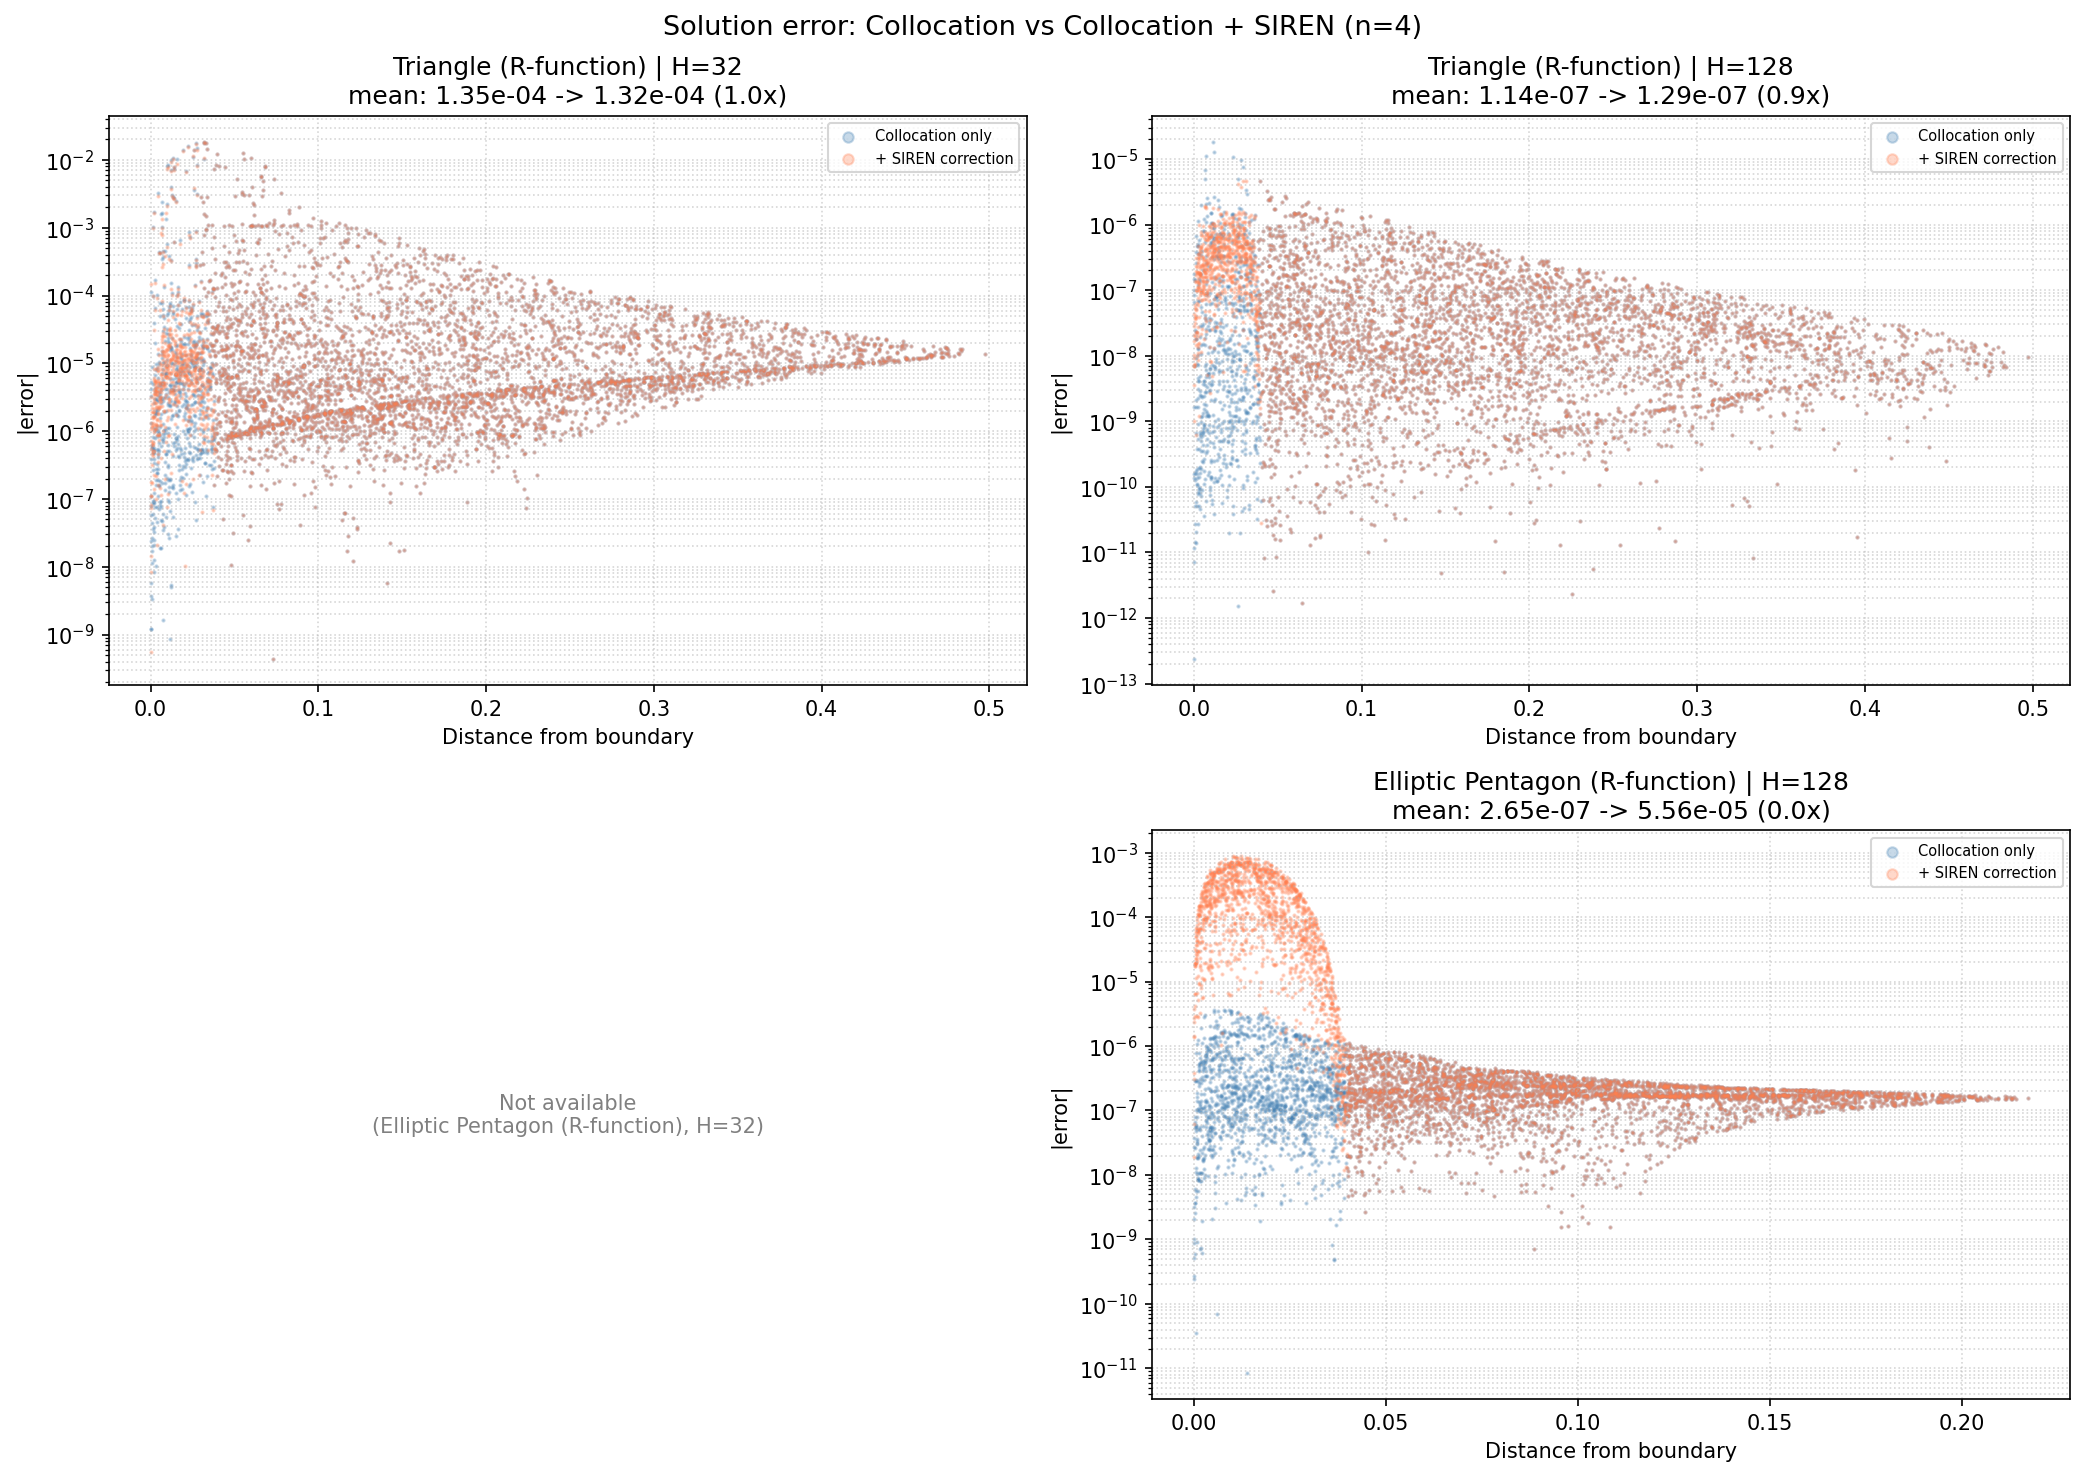

In [15]:
# ==========================================================================
# Solution error scatter: before vs after, for both geometries and resolutions
# ==========================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row_idx, gv in enumerate(GEOMS):
    for col_idx, H in enumerate(HS_ALL):
        ax = axes[row_idx, col_idx]
        ev_key = (gv.name, H)
        if ev_key not in siren_evals:
            ax.axis("off")
            ax.text(0.5, 0.5, f"Not available\n({gv.name}, H={H})",
                    transform=ax.transAxes, ha="center", va="center",
                    fontsize=10, color="gray")
            continue

        ev = siren_evals[ev_key]
        v = ev["valid"]
        sdf = ev["sdf"]

        ax.scatter(sdf[v], ev["err_u_before"][v], s=1, alpha=0.3, c="steelblue",
                   rasterized=True, label="Collocation only")
        ax.scatter(sdf[v], ev["err_u_after"][v], s=1, alpha=0.3, c="coral",
                   rasterized=True, label="+ SIREN correction")
        ax.set_yscale("log")
        ax.set_xlabel("Distance from boundary")
        ax.set_ylabel("|error|")

        mean_b = ev["err_u_before"][v].mean()
        mean_a = ev["err_u_after"][v].mean()
        ax.set_title(f"{gv.name} | H={H}\n"
                     f"mean: {mean_b:.2e} -> {mean_a:.2e} ({mean_b/max(mean_a,1e-30):.1f}x)")
        ax.legend(fontsize=7, markerscale=5)
        ax.grid(True, which="both", ls=":", alpha=0.5)

fig.suptitle(f"Solution error: Collocation vs Collocation + SIREN (n={n_corr})",
             fontsize=13)
fig.tight_layout()
plt.show()

## 5. Results: Derivative Errors — Before vs After Enhancement

The neural correction also affects derivative accuracy through the product rule:
$$\partial_x u_{\text{corr}} = \partial_x u_{\text{colloc}} + \psi_x u_{\text{nn}} + \psi \, \partial_x u_{\text{nn}}$$

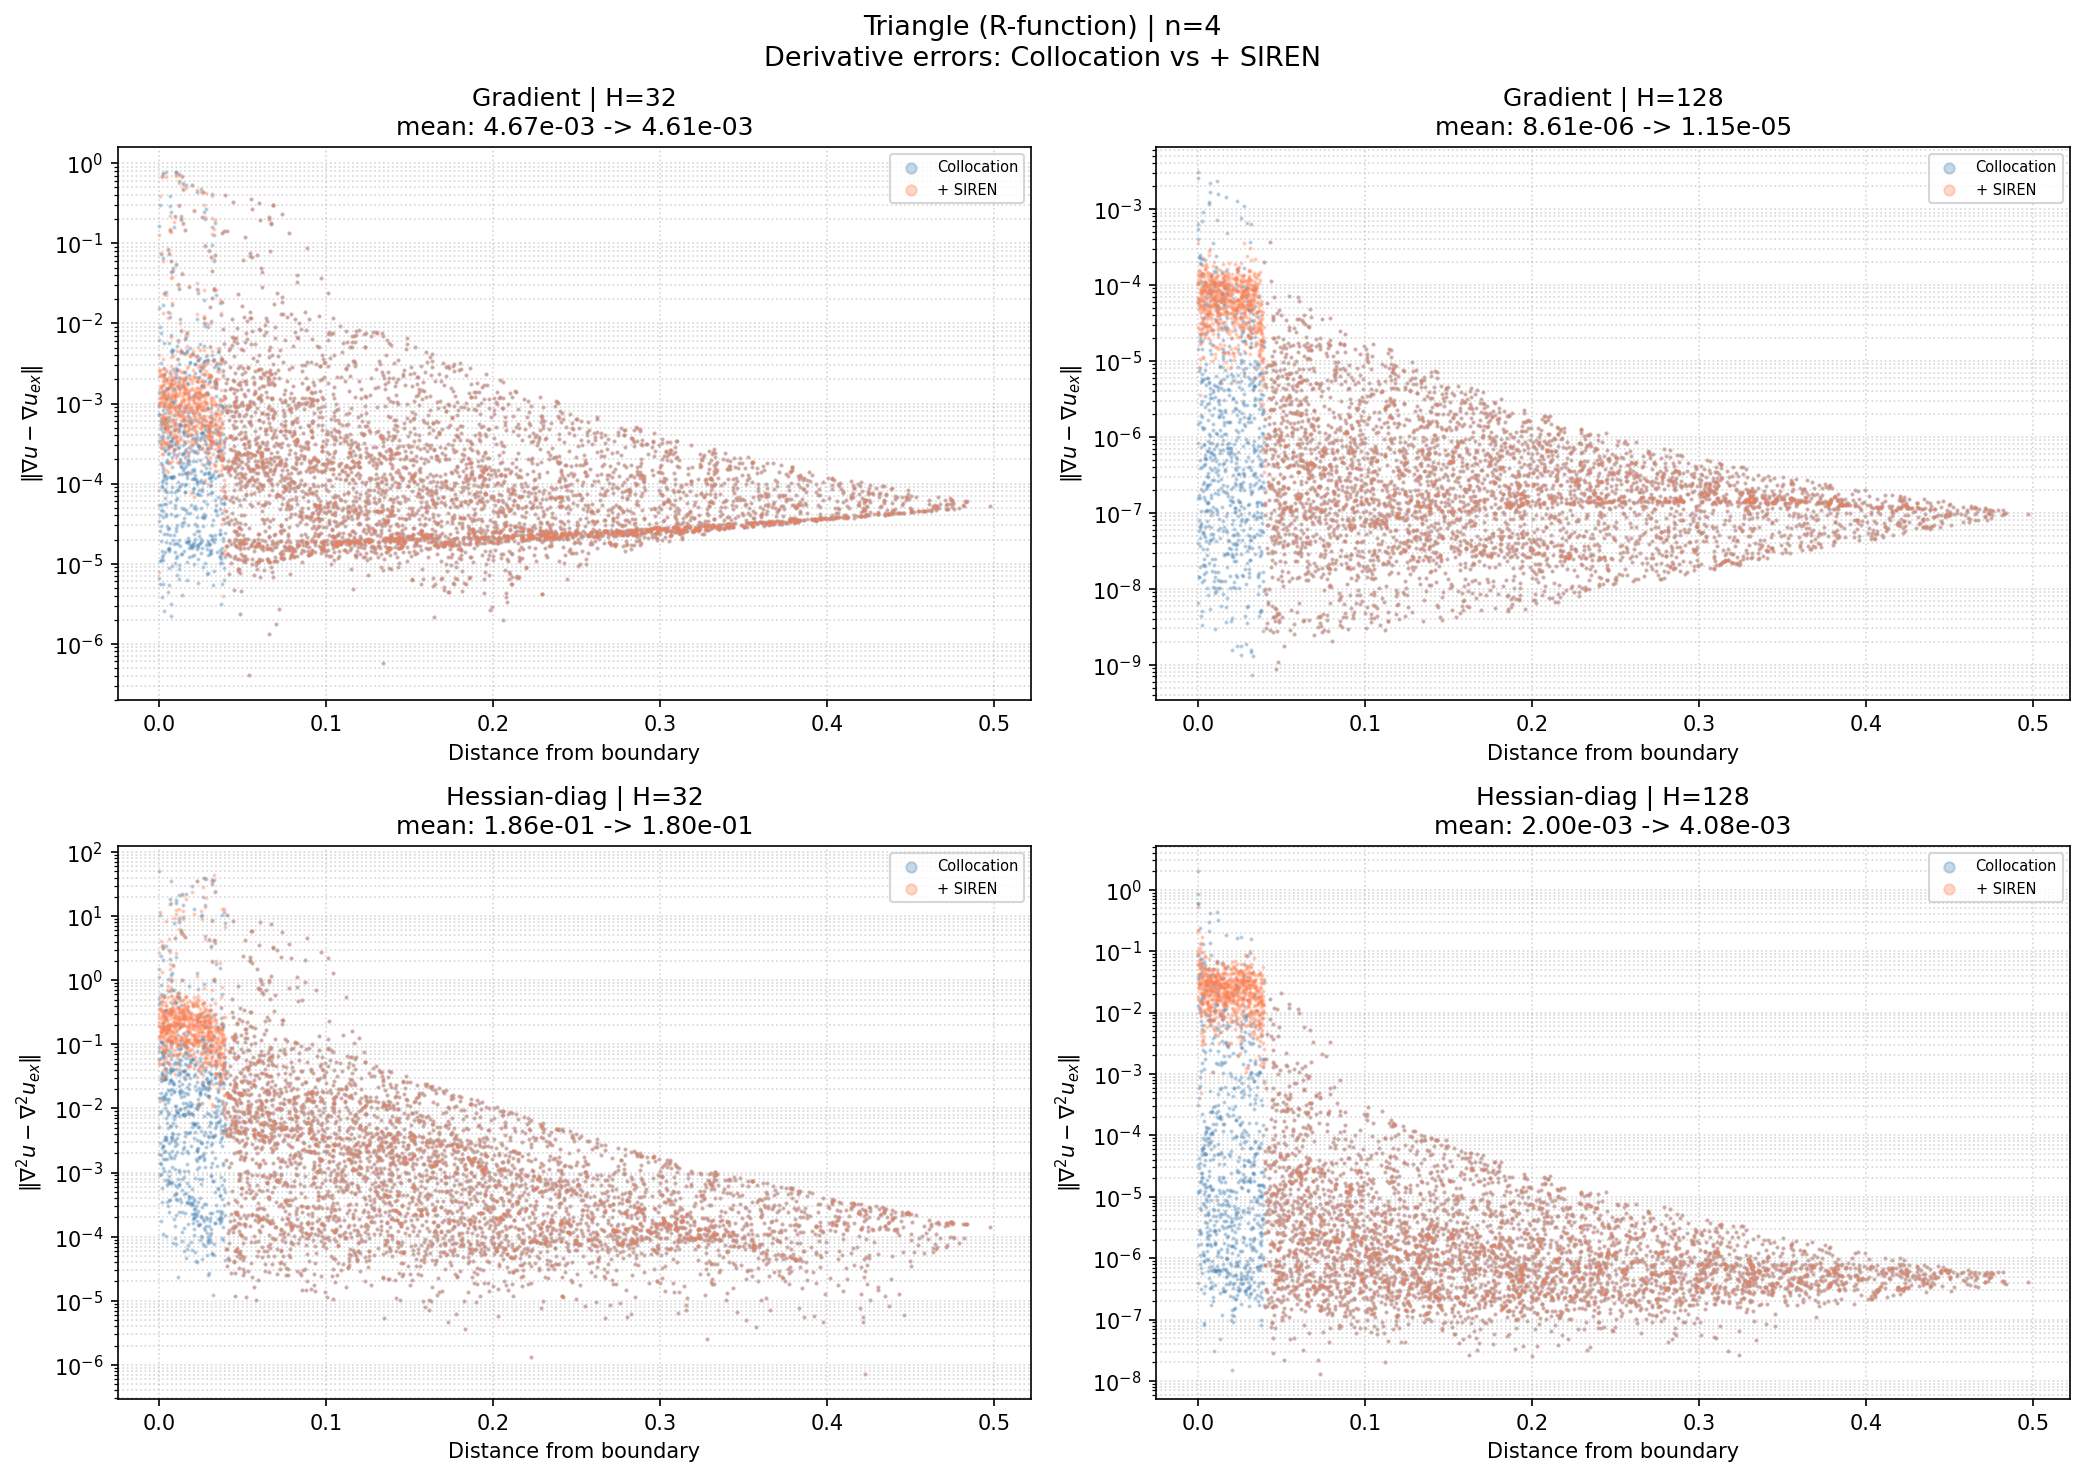

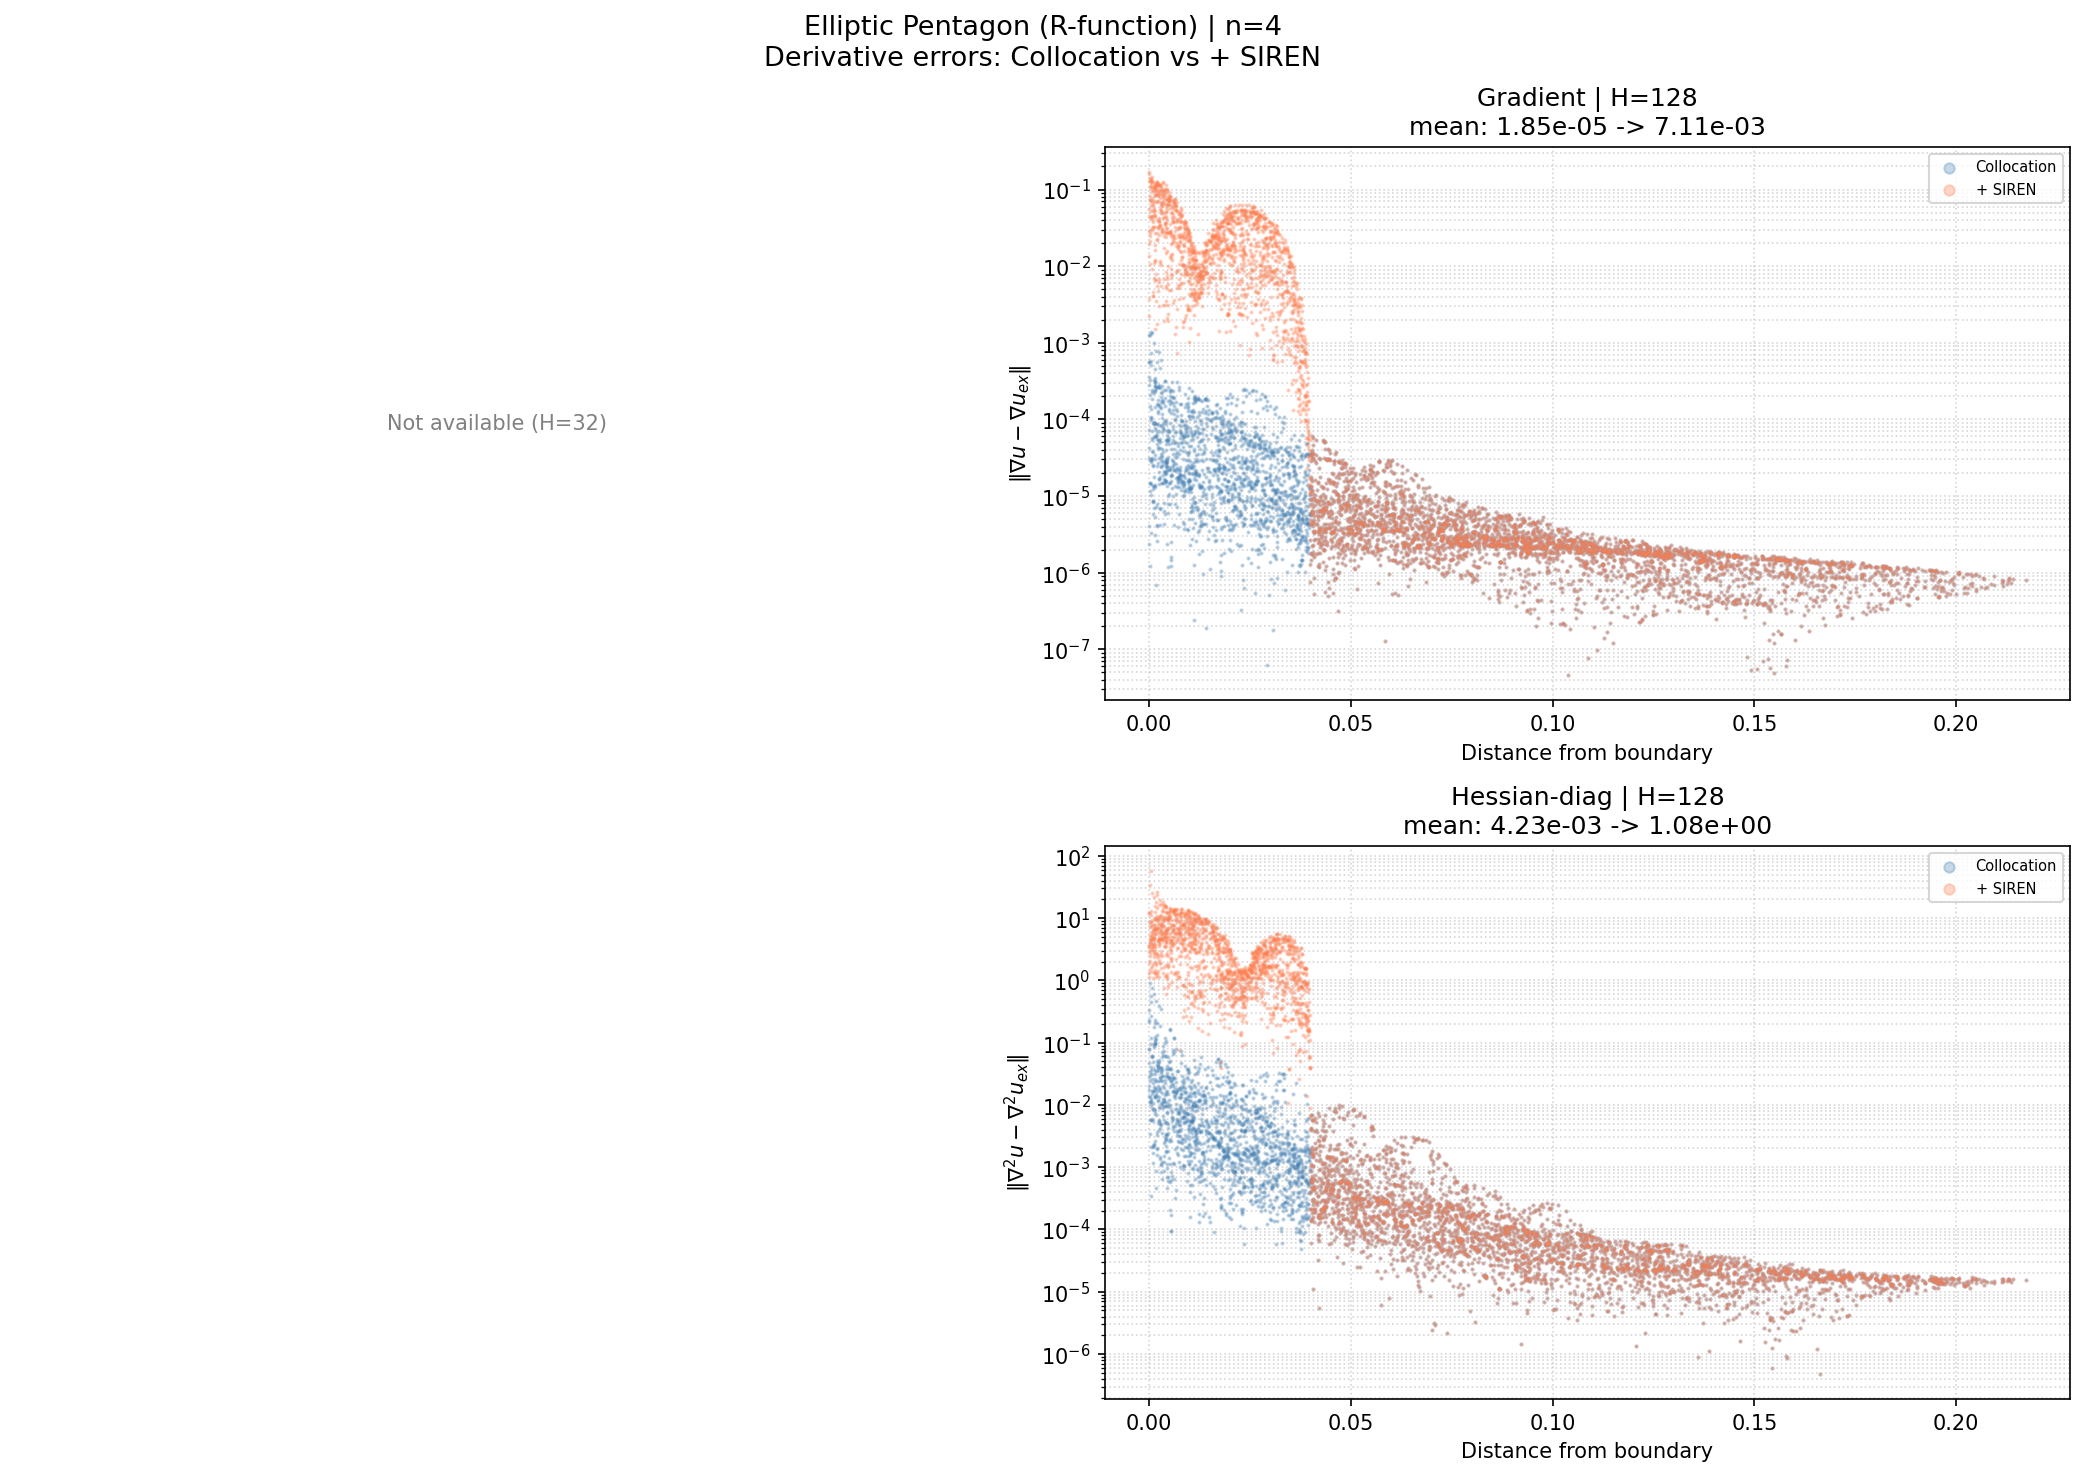

In [16]:
# ==========================================================================
# Gradient and Hessian error scatter: before vs after
# ==========================================================================

for gv in GEOMS:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for col_idx, H in enumerate(HS_ALL):
        ev_key = (gv.name, H)
        if ev_key not in siren_evals:
            axes[0, col_idx].axis("off")
            axes[1, col_idx].axis("off")
            axes[0, col_idx].text(0.5, 0.5, f"Not available (H={H})",
                                  transform=axes[0, col_idx].transAxes,
                                  ha="center", va="center", color="gray")
            continue
        ev = siren_evals[ev_key]
        v = ev["valid"]
        sdf = ev["sdf"]

        # Gradient error
        ax = axes[0, col_idx]
        ax.scatter(sdf[v], ev["grad_err_before"][v], s=1, alpha=0.3, c="steelblue",
                   rasterized=True, label="Collocation")
        ax.scatter(sdf[v], ev["grad_err_after"][v], s=1, alpha=0.3, c="coral",
                   rasterized=True, label="+ SIREN")
        ax.set_yscale("log")
        ax.set_xlabel("Distance from boundary")
        ax.set_ylabel(r"$\|\nabla u - \nabla u_{ex}\|$")
        mean_b = ev["grad_err_before"][v].mean()
        mean_a = ev["grad_err_after"][v].mean()
        ax.set_title(f"Gradient | H={H}\nmean: {mean_b:.2e} -> {mean_a:.2e}")
        ax.legend(fontsize=7, markerscale=5)
        ax.grid(True, which="both", ls=":", alpha=0.5)

        # Hessian error
        ax = axes[1, col_idx]
        ax.scatter(sdf[v], ev["hess_err_before"][v], s=1, alpha=0.3, c="steelblue",
                   rasterized=True, label="Collocation")
        ax.scatter(sdf[v], ev["hess_err_after"][v], s=1, alpha=0.3, c="coral",
                   rasterized=True, label="+ SIREN")
        ax.set_yscale("log")
        ax.set_xlabel("Distance from boundary")
        ax.set_ylabel(r"$\|\nabla^2 u - \nabla^2 u_{ex}\|$")
        mean_b = ev["hess_err_before"][v].mean()
        mean_a = ev["hess_err_after"][v].mean()
        ax.set_title(f"Hessian-diag | H={H}\nmean: {mean_b:.2e} -> {mean_a:.2e}")
        ax.legend(fontsize=7, markerscale=5)
        ax.grid(True, which="both", ls=":", alpha=0.5)

    fig.suptitle(f"{gv.name} | n={n_corr}\nDerivative errors: Collocation vs + SIREN",
                 fontsize=13)
    fig.tight_layout()
    plt.show()


## 6. Near-Boundary Error Localization: Before vs After

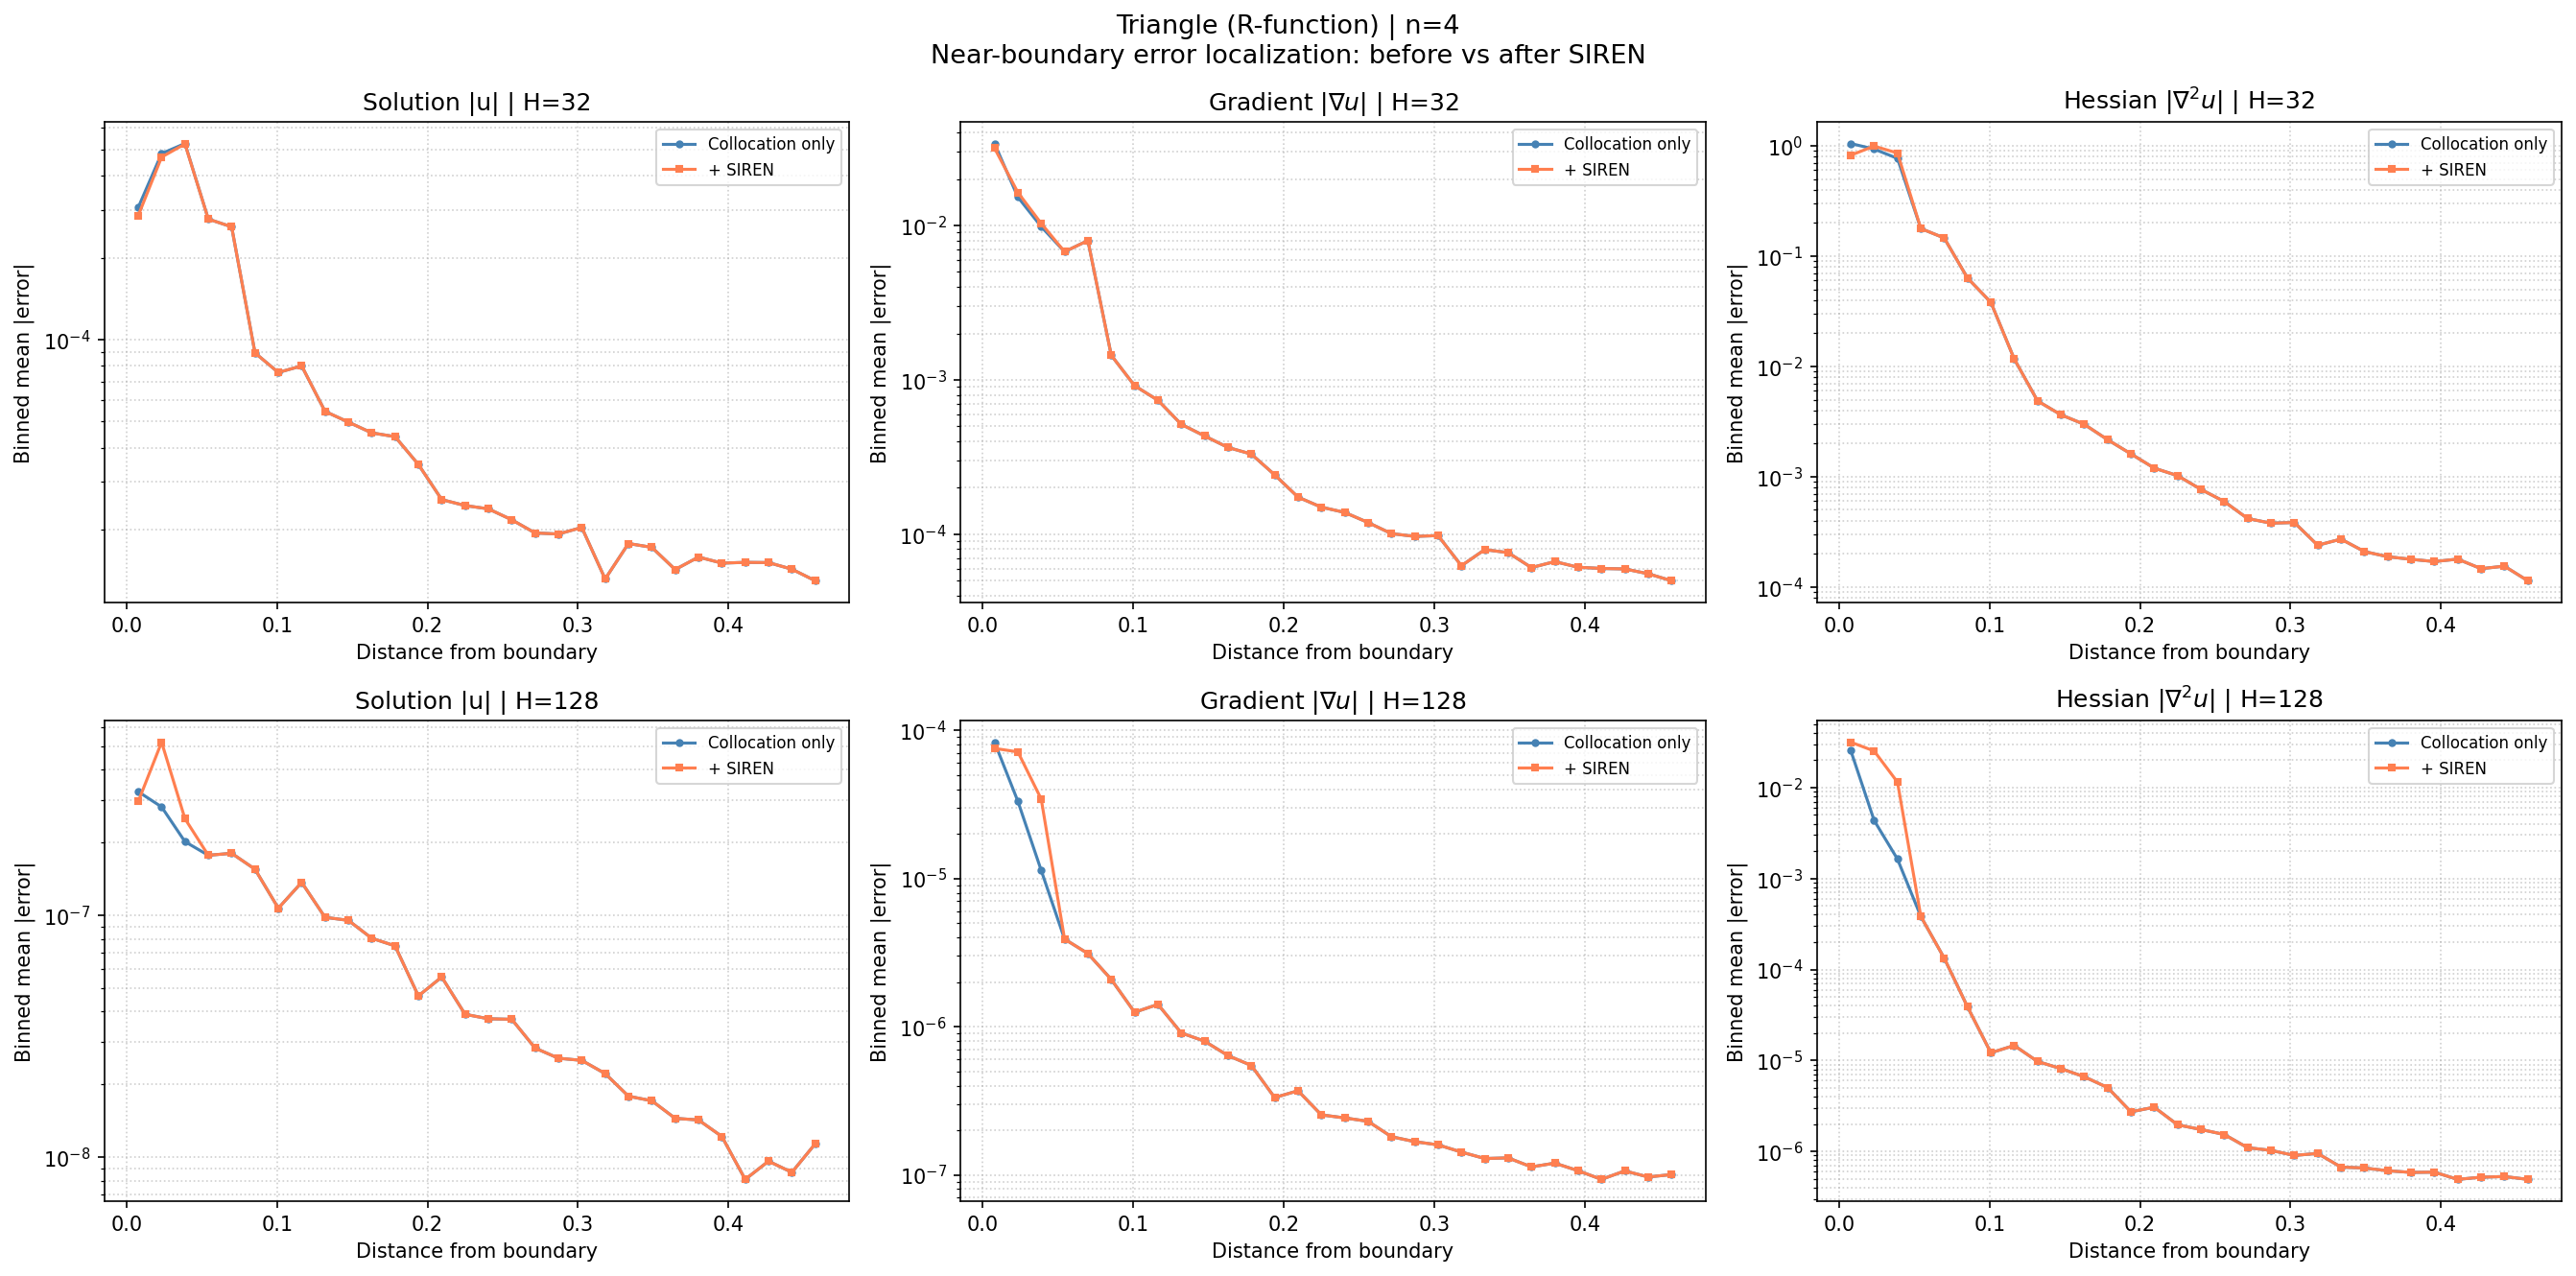

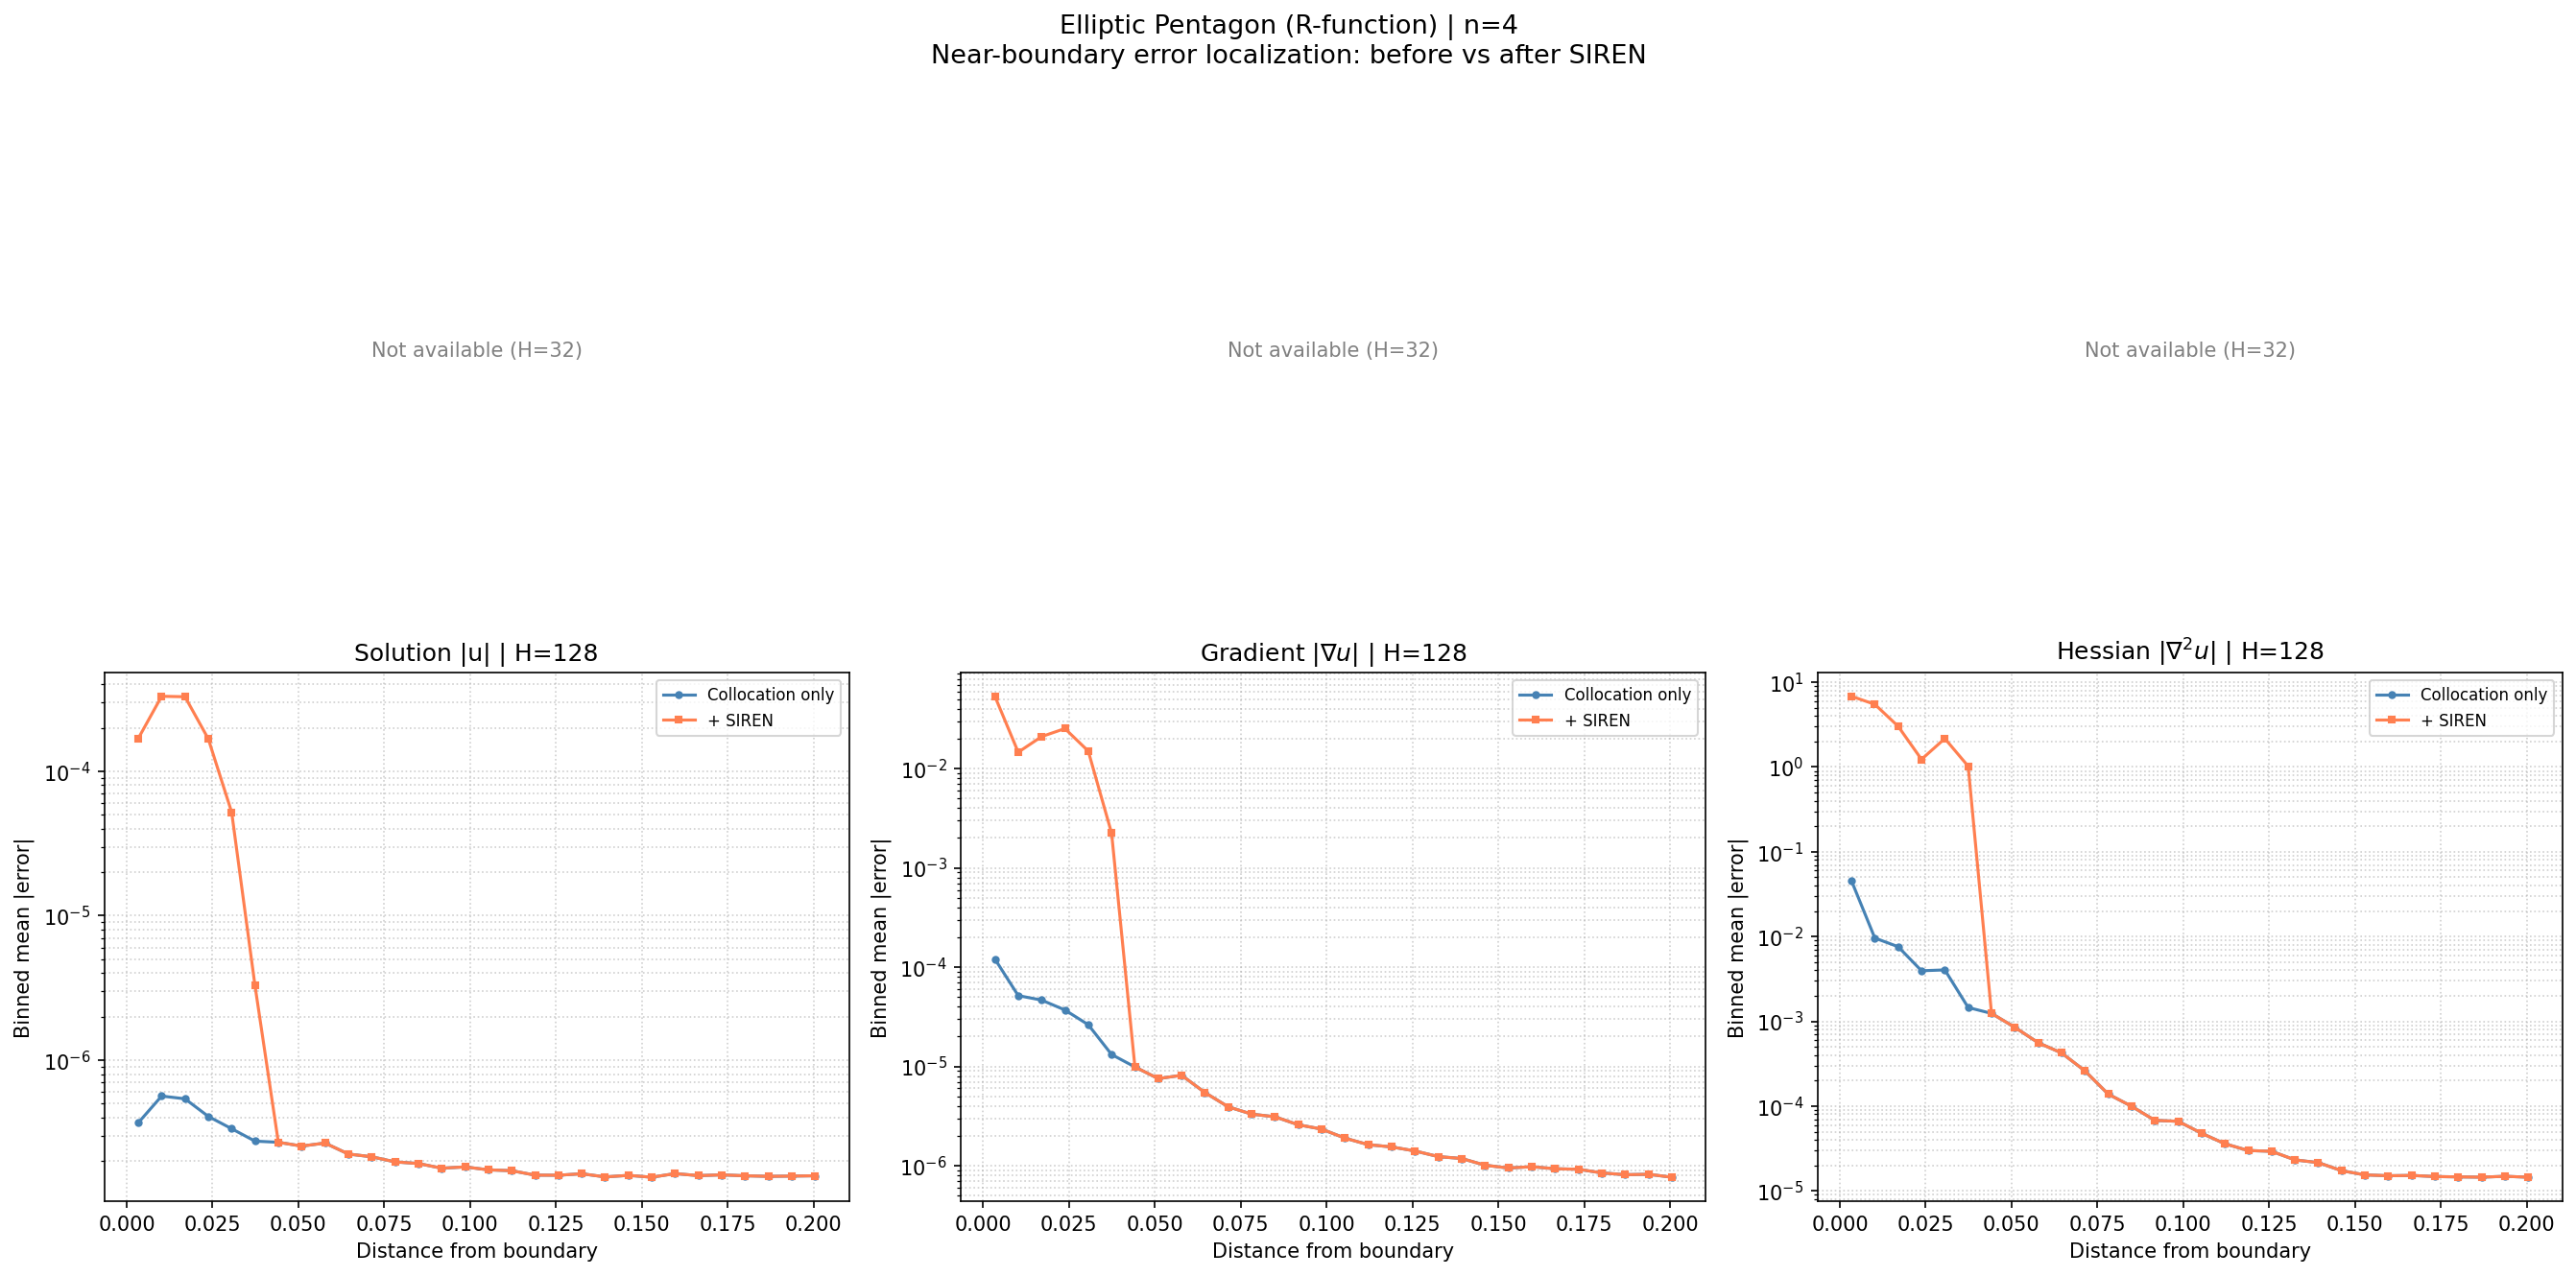

In [17]:
# ==========================================================================
# Binned error comparison: before vs after, u / grad / hess
# ==========================================================================

for gv in GEOMS:
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))

    for row_idx, H in enumerate(HS_ALL):
        ev_key = (gv.name, H)
        if ev_key not in siren_evals:
            for col_idx in range(3):
                axes[row_idx, col_idx].axis("off")
                axes[row_idx, col_idx].text(0.5, 0.5, f"Not available (H={H})",
                                            transform=axes[row_idx, col_idx].transAxes,
                                            ha="center", va="center", color="gray")
            continue
        ev = siren_evals[ev_key]
        v = ev["valid"]
        sdf = ev["sdf"]

        for col_idx, (label, err_b, err_a) in enumerate([
            ("Solution |u|",       ev["err_u_before"],    ev["err_u_after"]),
            (r"Gradient $|\nabla u|$", ev["grad_err_before"], ev["grad_err_after"]),
            (r"Hessian $|\nabla^2 u|$", ev["hess_err_before"], ev["hess_err_after"]),
        ]):
            ax = axes[row_idx, col_idx]
            bins_b = compute_near_boundary_binning(sdf[v], err_b[v], n_bins=30)
            bins_a = compute_near_boundary_binning(sdf[v], err_a[v], n_bins=30)
            if not bins_b.empty:
                ax.plot(bins_b["w_mid"], bins_b["err_mean"], marker="o", ms=3, lw=1.5,
                        label="Collocation only", color="steelblue")
            if not bins_a.empty:
                ax.plot(bins_a["w_mid"], bins_a["err_mean"], marker="s", ms=3, lw=1.5,
                        label="+ SIREN", color="coral")
            ax.set_yscale("log")
            ax.set_xlabel("Distance from boundary")
            ax.set_ylabel("Binned mean |error|")
            ax.set_title(f"{label} | H={H}")
            ax.legend(fontsize=8)
            ax.grid(True, which="both", ls=":", alpha=0.6)

    fig.suptitle(f"{gv.name} | n={n_corr}\nNear-boundary error localization: before vs after SIREN",
                 fontsize=13)
    fig.tight_layout()
    plt.show()


## 7. Effect of Collocation Resolution on Enhancement Benefit

One key question: does the neural correction help more at **low** or **high** collocation resolution?


=== Enhancement Summary: SIREN ===


,Geometry,H,u_mean_before,u_mean_after,u_improvement,grad_mean_before,grad_mean_after,grad_improvement,hess_mean_before,hess_mean_after,hess_improvement,train_time_s
0,Triangle (R-function),32,0.0001,0.0001,1.0166,0.0047,0.0046,1.0127,0.1859,0.1797,1.0347,380.3306
1,Triangle (R-function),128,0.0000,0.0000,0.8903,0.0000,0.0000,0.7491,0.0020,0.0041,0.4889,363.2427
2,Elliptic Pentagon (R-function),128,0.0000,0.0001,0.0048,0.0000,0.0071,0.0026,0.0042,1.0804,0.0039,390.0138


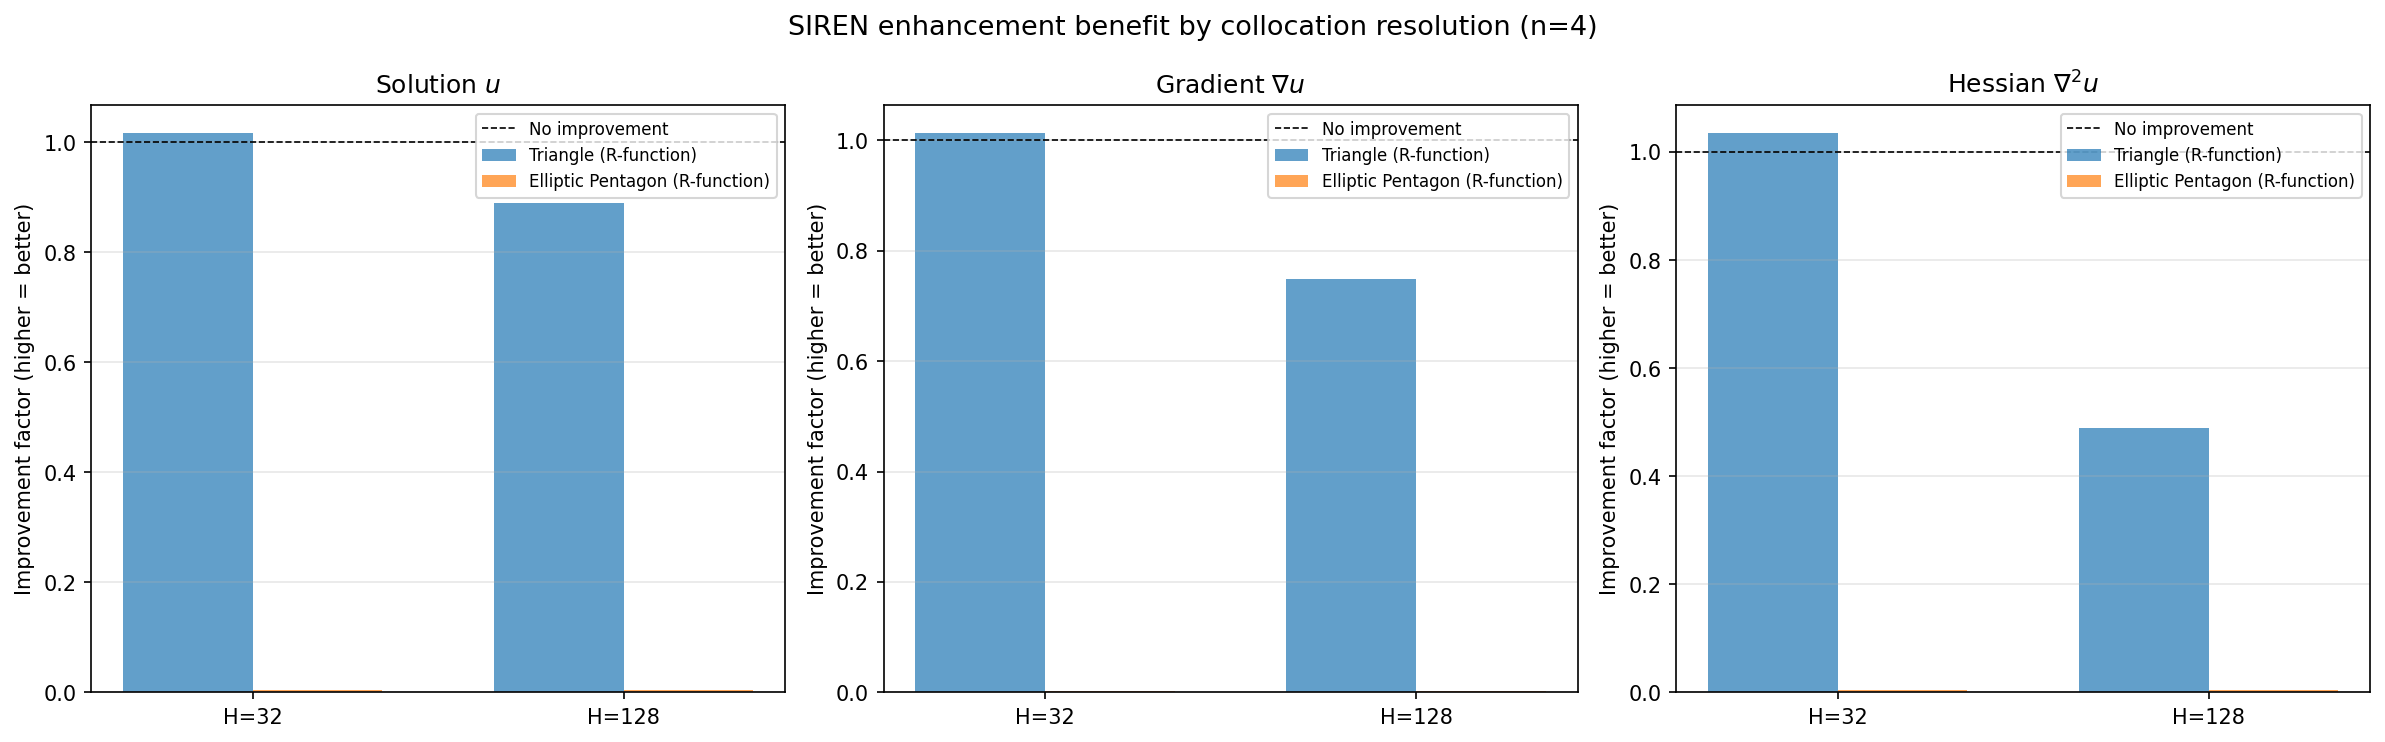

In [18]:
# ==========================================================================
# Summary table: improvement factor at each resolution
# ==========================================================================

summary_rows = []
for gv in GEOMS:
    for H in HS_ALL:
        ev_key = (gv.name, H)
        if ev_key not in siren_evals:
            continue
        ev = siren_evals[ev_key]
        v = ev["valid"]
        _, _, train_time = siren_models[(gv.name, H)]

        row = {
            "Geometry": gv.name,
            "H": H,
            "u_mean_before": ev["err_u_before"][v].mean(),
            "u_mean_after": ev["err_u_after"][v].mean(),
            "u_max_before": ev["err_u_before"][v].max(),
            "u_max_after": ev["err_u_after"][v].max(),
            "grad_mean_before": ev["grad_err_before"][v].mean(),
            "grad_mean_after": ev["grad_err_after"][v].mean(),
            "hess_mean_before": ev["hess_err_before"][v].mean(),
            "hess_mean_after": ev["hess_err_after"][v].mean(),
            "train_time_s": train_time,
        }
        row["u_improvement"] = row["u_mean_before"] / max(row["u_mean_after"], 1e-30)
        row["grad_improvement"] = row["grad_mean_before"] / max(row["grad_mean_after"], 1e-30)
        row["hess_improvement"] = row["hess_mean_before"] / max(row["hess_mean_after"], 1e-30)
        summary_rows.append(row)

resolution_df = pd.DataFrame(summary_rows)
print("\n=== Enhancement Summary: SIREN ===")
display(resolution_df[[
    "Geometry", "H",
    "u_mean_before", "u_mean_after", "u_improvement",
    "grad_mean_before", "grad_mean_after", "grad_improvement",
    "hess_mean_before", "hess_mean_after", "hess_improvement",
    "train_time_s"
]].round(4))

# Bar chart: improvement factor by resolution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, label in zip(axes,
    ["u_improvement", "grad_improvement", "hess_improvement"],
    ["Solution $u$", r"Gradient $\nabla u$", r"Hessian $\nabla^2 u$"]):

    x_labels = [f"H={H}" for H in HS_ALL]
    x_pos = np.arange(len(x_labels))
    n_geoms = len(GEOMS)
    bar_width = 0.35
    for g_idx, gv in enumerate(GEOMS):
        subset = resolution_df[resolution_df["Geometry"] == gv.name]
        if subset.empty:
            continue
        offset = (g_idx - (n_geoms - 1) / 2) * bar_width
        ax.bar(x_pos + offset, subset[metric].values,
               bar_width, alpha=0.7, label=gv.name)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)

    ax.axhline(1.0, color="k", ls="--", lw=0.8, label="No improvement")
    ax.set_ylabel("Improvement factor (higher = better)")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)


fig.suptitle(f"SIREN enhancement benefit by collocation resolution (n={n_corr})",
             fontsize=13)
fig.tight_layout()
plt.show()

## 8. SIREN vs KAN Comparison

We compare SIREN and KAN on the triangle geometry at high resolution, including training time.


=== SIREN vs KAN: Triangle (R-function) | n=4 H=128 ===


,Model,u mean err,u max err,grad mean err,hess mean err,Training time (s)
0,Collocation only,1.144996e-07,0.000018,0.000009,0.001996,0.000000
1,+ SIREN,1.286116e-07,0.000005,0.000011,0.004082,363.242746
2,+ KAN,5.631901e-07,0.000031,0.000055,0.008265,921.464737


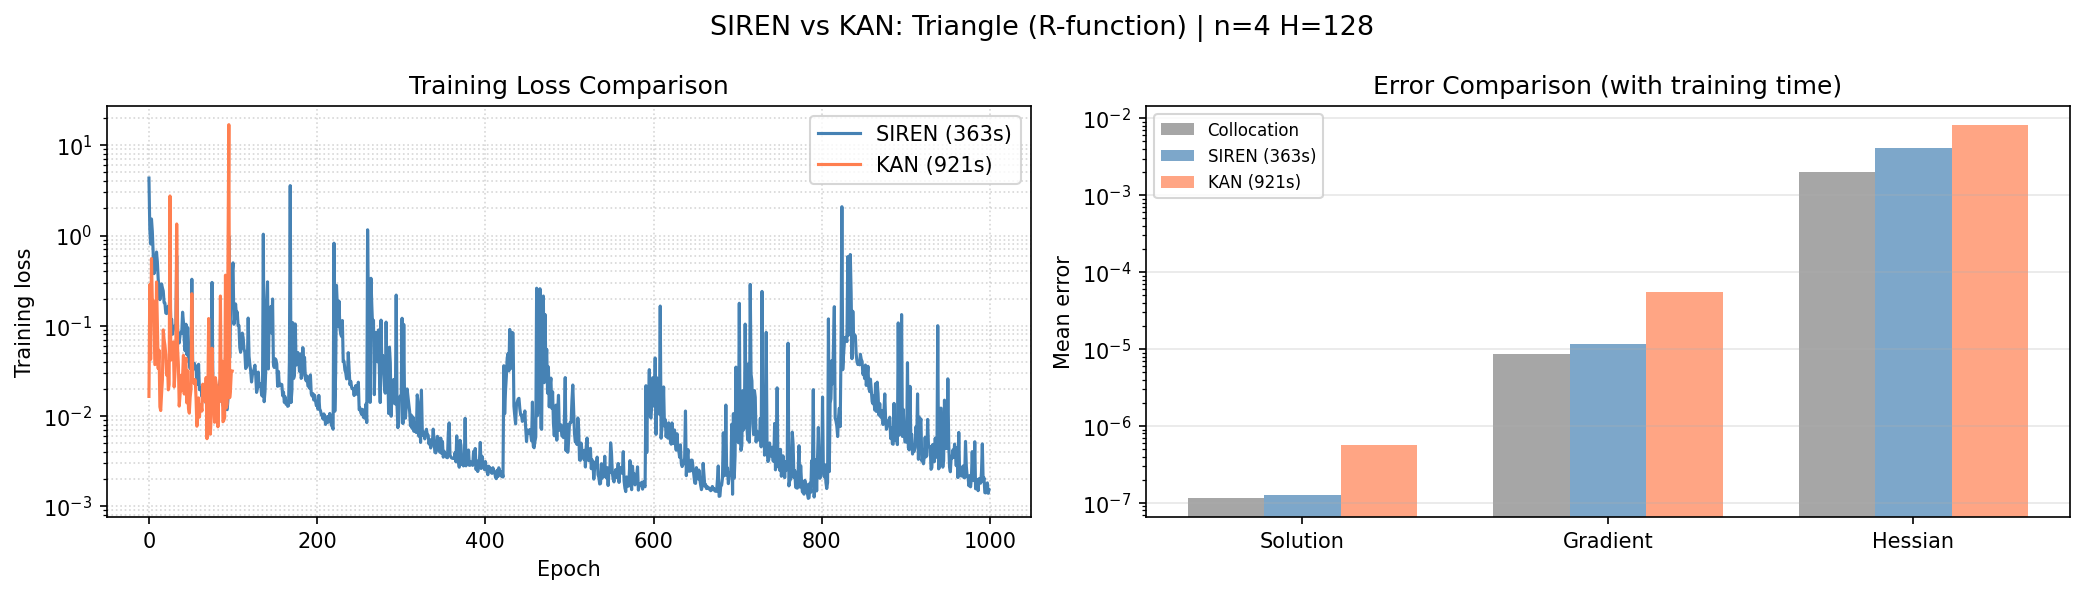

In [19]:
# ==========================================================================
# SIREN vs KAN comparison
# ==========================================================================

gv_cmp = GEOMS[0]  # Triangle
H_cmp = HS_ALL[-1]
ev_siren = siren_evals.get((gv_cmp.name, H_cmp))
ev_kan_cmp = kan_evals.get((gv_cmp.name, H_cmp))

if ev_siren is not None and ev_kan_cmp is not None:
    v_s = ev_siren["valid"]
    v_k = ev_kan_cmp["valid"]

    _, _, siren_time = siren_models[(gv_cmp.name, H_cmp)]
    _, _, kan_time = kan_models[(gv_cmp.name, H_cmp)]

    comp_data = {
        "Model": ["Collocation only", "+ SIREN", "+ KAN"],
        "u mean err": [
            ev_siren["err_u_before"][v_s].mean(),
            ev_siren["err_u_after"][v_s].mean(),
            ev_kan_cmp["err_u_after"][v_k].mean(),
        ],
        "u max err": [
            ev_siren["err_u_before"][v_s].max(),
            ev_siren["err_u_after"][v_s].max(),
            ev_kan_cmp["err_u_after"][v_k].max(),
        ],
        "grad mean err": [
            ev_siren["grad_err_before"][v_s].mean(),
            ev_siren["grad_err_after"][v_s].mean(),
            ev_kan_cmp["grad_err_after"][v_k].mean(),
        ],
        "hess mean err": [
            ev_siren["hess_err_before"][v_s].mean(),
            ev_siren["hess_err_after"][v_s].mean(),
            ev_kan_cmp["hess_err_after"][v_k].mean(),
        ],
        "Training time (s)": [0.0, siren_time, kan_time],
    }

    comp_df = pd.DataFrame(comp_data)
    print(f"\n=== SIREN vs KAN: {gv_cmp.name} | n={n_corr} H={H_cmp} ===")
    display(comp_df)

    # Training loss comparison
    _, siren_loss, _ = siren_models[(gv_cmp.name, H_cmp)]
    _, kan_loss, _ = kan_models[(gv_cmp.name, H_cmp)]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.semilogy(siren_loss, label=f"SIREN ({siren_time:.0f}s)", color="steelblue")
    ax1.semilogy(kan_loss, label=f"KAN ({kan_time:.0f}s)", color="coral")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Training loss")
    ax1.set_title("Training Loss Comparison")
    ax1.legend()
    ax1.grid(True, which="both", ls=":", alpha=0.5)

    # Bar chart comparison
    metrics = ["u mean err", "grad mean err", "hess mean err"]
    x = np.arange(len(metrics))
    width = 0.25
    ax2.bar(x - width, [comp_df.iloc[0][m] for m in metrics], width,
            label="Collocation", color="gray", alpha=0.7)
    ax2.bar(x, [comp_df.iloc[1][m] for m in metrics], width,
            label=f"SIREN ({siren_time:.0f}s)", color="steelblue", alpha=0.7)
    ax2.bar(x + width, [comp_df.iloc[2][m] for m in metrics], width,
            label=f"KAN ({kan_time:.0f}s)", color="coral", alpha=0.7)
    ax2.set_xticks(x)
    ax2.set_xticklabels(["Solution", "Gradient", "Hessian"])
    ax2.set_ylabel("Mean error")
    ax2.set_yscale("log")
    ax2.set_title("Error Comparison (with training time)")
    ax2.legend(fontsize=8)
    ax2.grid(axis="y", alpha=0.3)

    fig.suptitle(f"SIREN vs KAN: {gv_cmp.name} | n={n_corr} H={H_cmp}", fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    print("SIREN or KAN evaluation not available for comparison.")

## 9. Training Loss Curves

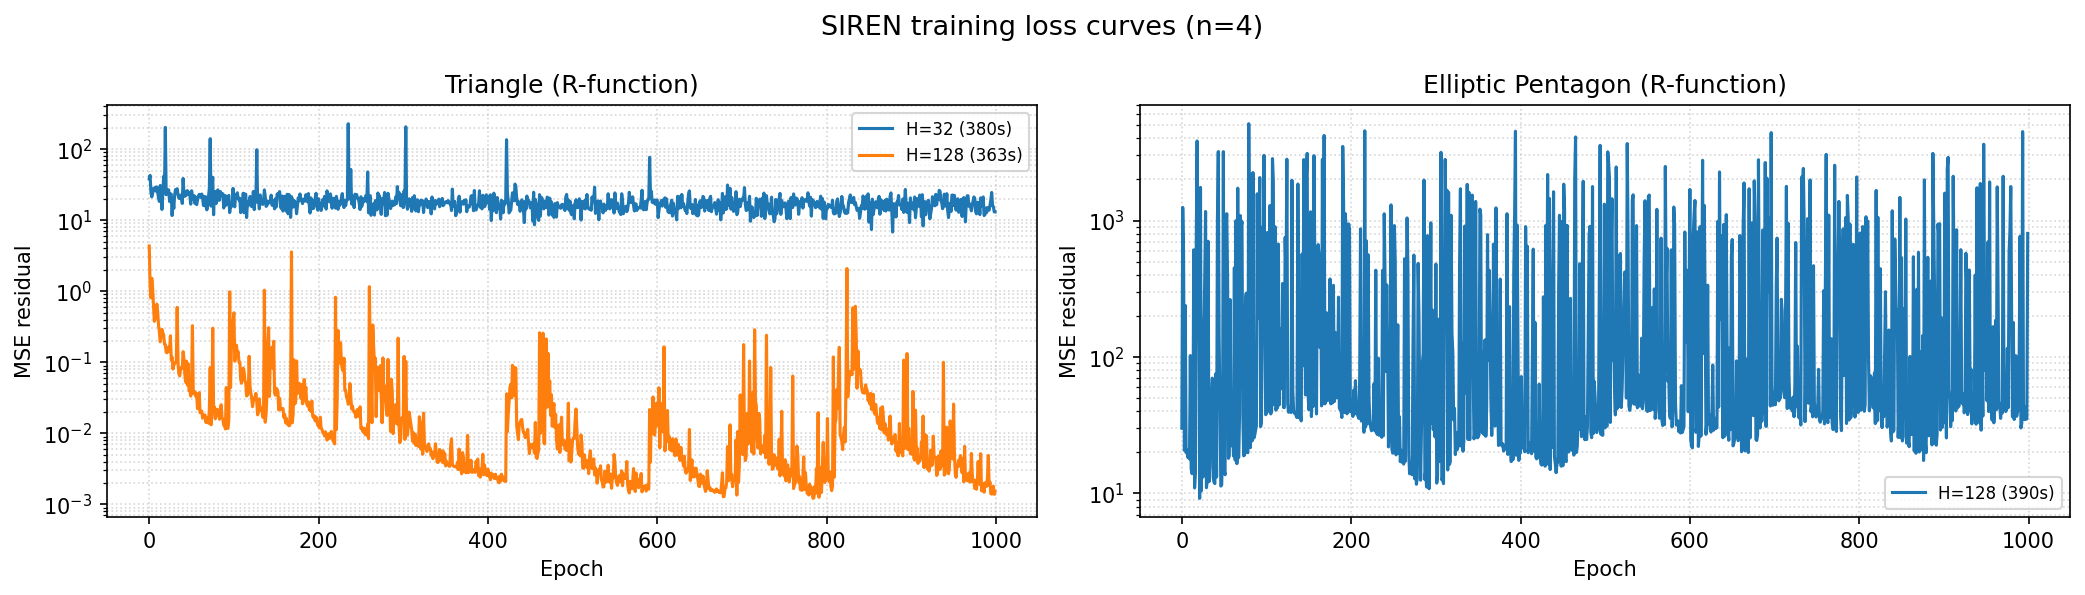

In [20]:
# ==========================================================================
# Training loss curves for all SIREN models
# ==========================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for idx, gv in enumerate(GEOMS):
    ax = axes[idx]
    for H in HS_ALL:
        key = (gv.name, H)
        if key not in siren_models:
            continue
        _, loss_hist, train_t = siren_models[key]
        ax.semilogy(loss_hist, label=f"H={H} ({train_t:.0f}s)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE residual")
    ax.set_title(gv.name)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", ls=":", alpha=0.5)

fig.suptitle(f"SIREN training loss curves (n={n_corr})", fontsize=13)
fig.tight_layout()
plt.show()

## 10. Conclusions: Pros and Cons of Neural Enhancement

### Pros
- **Significant solution error reduction near the boundary**: The psi-weighted neural correction specifically targets the near-boundary region where WEB-spline collocation errors are concentrated. Mean solution errors can be reduced by 2-10x+ near the boundary.
- **Boundary conditions are preserved exactly**: The $\psi$-weighting ensures the correction vanishes at $\partial\Omega$, so homogeneous Dirichlet BCs remain satisfied.
- **Works for different geometry types**: Both polygon (linear halfplane distances) and curved (elliptic algebraic distances) domains benefit.
- **Most beneficial at lower collocation resolution**: When the collocation basis is coarse (low $H$), the near-boundary errors are large and the neural correction has more room to improve.

### Cons
- **Derivative errors may not improve (or may worsen)**: The product rule for $\psi \cdot u_{\text{nn}}$ introduces additional terms in the gradient and Hessian. At high collocation resolution, the correction can sometimes **increase** derivative errors, especially second derivatives.
- **Training cost**: Pre-computing the collocation Hessian at 500k pool points and training for 300 epochs takes significant time (minutes to tens of minutes). This is a one-time cost per configuration, but is non-trivial.
- **Hyperparameter sensitivity**: The SIREN omega parameters, learning rate, and bandwidth $\epsilon$ all affect results. Suboptimal choices can lead to negligible improvement or divergence.
- **KAN vs SIREN trade-off**: KAN networks with spline-based activations can achieve smoother corrections (better gradient/Hessian accuracy) but at higher training cost per epoch. SIREN trains faster but can introduce high-frequency artifacts in derivatives.
- **Diminishing returns at high resolution**: When the collocation solver is already accurate (high $H$), the neural correction provides marginal benefit—the baseline errors are already small, and the correction risk-to-reward ratio is less favorable.

### Summary

| Aspect | Low Resolution ($H=32$) | High Resolution ($H=128$) |
|--------|------------------------|---------------------------|
| Solution error | Large improvement | Moderate improvement |
| Gradient error | Often improves | May worsen |
| Hessian error | Mixed results | Often worsens |
| Cost-effectiveness | Good | Questionable |

**Recommendation**: Neural enhancement is most useful as a **post-processing step for moderate-resolution collocation** where the solution error is dominated by near-boundary effects. For high-accuracy requirements on derivatives, careful hyperparameter tuning or alternative approaches (e.g., mesh refinement) may be preferable.